In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random
from scipy.stats import beta
from scipy.spatial.distance import cdist

import keras
import bayesflow as bf
from functools import partial

import numba as nb
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
RNG = np.random.default_rng(SEED)
rng_states = create_xoroshiro128p_states(2000*2400, seed=SEED)

INFO:bayesflow:Using backend 'jax'


In [2]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "jax", "jaxlib"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")

print("\n=== CUDA / GPU Info ===")
try:
    print(f"CUDA available: {cuda.is_available()}")
    if cuda.is_available():
        print(f"GPU: {cuda.get_current_device().name}")
except Exception as e:
    print(f"CUDA check failed: {e}")

=== Python ===
3.11.3 (main, Aug 13 2025, 16:49:22) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
jax: 0.4.28
jaxlib: 0.4.28

=== CUDA / GPU Info ===
CUDA available: True
GPU: b'NVIDIA H100 80GB HBM3'


## Single trial simulation
The following cells implement the core simulation using raw CUDA kernels.
**You do not need to modify this code** to customize the model.


In [3]:
#device = True compiles a utility function that can be called within a kernel
@cuda.jit(device=True)
def add_diagonal(matrix, value, n):
    for i in range(n):
        matrix[i, i] += value

@cuda.jit(device=True)
def rbf_kernel(x1, x2, rho):
    diff = x1 - x2
    sqdist = diff * diff
    return math.exp(-0.5 * sqdist / (rho * rho))

@cuda.jit(device=True)
def cholesky_decomp_inplace(A, n):
    """
    Performs an in-place Cholesky decomposition of a positive-definite matrix A.
    The lower triangular matrix L, where A = L * L^T, will overwrite the
    lower triangle of the input matrix A.
    """
    for i in range(n):
        for j in range(i + 1):
            sum_val = 0.0
            for k in range(j):
                sum_val += A[i, k] * A[j, k]
            
            if i == j:
                val = A[i, i] - sum_val
                if val <= 0.0:
                    val = 1e-8 # Add epsilon for numerical stability
                A[i, j] = math.sqrt(val)
            else:
                if A[j, j] == 0.0: # Avoid division by zero
                    A[i, j] = 0.0
                else:
                    A[i, j] = (A[i, j] - sum_val) / A[j, j]

@cuda.jit(device=True)
def beta_pdf(x, alpha, beta):
    if x <= 0.0 or x >= 1.0 or alpha <= 0.0 or beta <= 0.0:
        return 0.0
    log_pdf = (alpha - 1.0) * math.log(x) \
            + (beta - 1.0) * math.log(1.0 - x) \
            - (math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta))
    return math.exp(log_pdf)


#this is the true kernel function
@cuda.jit
def cuda_diffusion_trial_bddm(rng_states, out_rt, out_resp, in_mu, in_kappa, in_h,
                                     in_a, in_ndt, in_rho,
                                     dt, max_steps, num_threads,
                                     x):
    # The simulation ID is now the block index.
    sim_id = cuda.blockIdx.x
    
    # The thread index within the block.
    tx = cuda.threadIdx.x
    
    # Total threads in the current block.
    block_dim = cuda.blockDim.x
    
    n = x.shape[0]  # number of points (100)

    if sim_id >= num_threads:
        return

    # --- SHARED MEMORY ---
    #these arrays are shared within a block
    K = cuda.shared.array((101, 101), dtype=float32)
    drift_profile = cuda.shared.array(101, dtype=float32)
    f = cuda.shared.array(101, dtype=float32)
    z = cuda.shared.array(101, dtype=float32)
    f_new = cuda.shared.array(101, dtype=float32)
    scratch      = cuda.shared.array(128,  dtype=float32)

    # A shared flag to signal when a boundary has been crossed.
    stop_flag = cuda.shared.array(1, dtype=int32)
    
    # Load parameters for this simulation (once per block)
    mu = in_mu[sim_id]
    kappa = in_kappa[sim_id]
    h = in_h[sim_id]
    a = in_a[sim_id]
    ndt = in_ndt[sim_id]
    rho = in_rho[sim_id]
    
    
    # --- PARALLEL PRECOMPUTATION ---
    # Threads cooperate to compute the drift profile and K matrix.
    
    # Compute drift profile in parallel
    # range(start, stop, step)
    # for tx = 0, range(0, 100, 128), i = 0
    # for tx = 1, range(1, 100, 128), i = 1
    # so that drift_profile calculation was distributed to the 100 threads
    # the work is done with a single pass
    for i in range(tx, n, block_dim):
        drift_profile[i] = h * beta_pdf(x[i, 0], mu * kappa, kappa - mu * kappa)

    # Compute RBF kernel matrix K in parallel
    for i in range(tx, n, block_dim):
        for j in range(n):
            K[i, j] = rbf_kernel(x[i, 0], x[j, 0], rho)
    
    # Wait for all threads to finish writing to K and drift_profile.
    cuda.syncthreads()

    # --- SERIAL CHOLESKY DECOMPOSITION ---
    # One thread computes the in-place decomposition on the shared K matrix.
    # Although there is loop within cholesky_decomp_inplace()
    # that function is inherently sequential
    if tx == 0:
        add_diagonal(K, 1e-6, n)
        cholesky_decomp_inplace(K, n)
        
        # Initialize process f
        for i in range(n):
            f[i] = 0.0

    # Wait for thread 0 to finish computing L (in K) and initializing f.
    cuda.syncthreads()
    
    stop_time = -1.0
    sqrt_dt = math.sqrt(dt)
    
    # --- TIME INTEGRATION LOOP ---
    for t in range(max_steps):
        # reset stop flag
        if tx == 0:
            stop_flag[0] = 0
        cuda.syncthreads()

        # generate random noise (one per spatial point)
        global_thread_id = sim_id * block_dim + tx
        for i in range(tx, n, block_dim):
            z[i] = xoroshiro128p_normal_float32(rng_states, global_thread_id)

        cuda.syncthreads()

        # correlated noise + drift integration
        for i in range(tx, n, block_dim):
            temp = 0.0
            for j in range(i + 1):   # K now holds Cholesky (lower-triangular)
                temp += K[i, j] * z[j]
            f_new[i] = f[i] + drift_profile[i] * dt + temp * sqrt_dt
        cuda.syncthreads()

        local_sum = float32(0.0)
        for i in range(tx, n, block_dim):
            local_sum += f_new[i]
        scratch[tx] = local_sum

        cuda.syncthreads()

        # Tree reduction: log2(128) = 7 steps instead of 101 serial steps
        s = block_dim // 2   # 64
        while s > 0:
            if tx < s:
                scratch[tx] += scratch[tx + s]
            cuda.syncthreads()
            s //= 2

        # scratch[0] now holds total sum; visible to all threads after last sync
        mean = scratch[0] / float32(n)

        for i in range(tx, n, block_dim):
            f_new[i] -= mean
        cuda.syncthreads()

        # --- Update f and check for boundary crossing ---
        for i in range(tx, n, block_dim):
            f[i] = f_new[i]
            if f[i] >= a:
                cuda.atomic.max(stop_flag, 0, 1)
        cuda.syncthreads()

        if stop_flag[0] > 0:
            if tx == 0:
                stop_time = (t + 1) * dt
            break  # all threads in block exit loop together

    # --- SAVE OUTPUT ---
    if tx == 0:
        if stop_time < 0.0:
            stop_time = max_steps * dt

        # find response (argmax)
        max_f_value = -1e9
        max_f_idx = 0
        for i in range(n):
            if f[i] > max_f_value:
                max_f_value = f[i]
                max_f_idx = i

        out_rt[sim_id] = stop_time + ndt
        out_resp[sim_id] = x[max_f_idx, 0]

## ⚙️Prior (customizable)

This function defines the prior distributions over all model parameters.
Modify the ranges below to match your experimental design.

### Parameter guide

| Parameter | Shape | Description | Default range |
|-----------|-------|-------------|---------------|
| `mu` | `(batch_size, n_conditions)` | Location of the beta distribution | [0.15, 0.85] |
| `kappa` | `(batch_size, n_conditions)` | Concentration of the beta distribution | [1/mu, 20] |
| `h` | `(batch_size, n_conditions)` | Scale parameter for height of the beta distribution| [0.2, 3] |
| `a` | `(batch_size, 1)` | Decision threshold | [0.5, 7] |
| `ndt` | `(batch_size, 1)` | Non-decision time (seconds) | [0.1, 2.5] |
| `rho` | `(batch_size, 1)` | RBF kernel lengthscale | [0.01, 0.5] |

### Common modifications

**Change parameter ranges:**
```python
a = rng.uniform(0.5, 7, size=batch_size)  # change 0.5 and 7
```

**Change number of conditions** (default: 4):
```python
mu = rng.uniform(0.15, 0.85, size=(batch_size, 4))  # change 4 → your n_conditions
h  = rng.uniform(0.2, 3,    size=(batch_size, 4))   # change 4 → your n_conditions
```

**Make a shared parameter condition-specific:**
```python
# shared (current default)
a = rng.uniform(0.5, 7, size=batch_size)

# condition-specific
a = rng.uniform(0.5, 7, size=(batch_size, 4))  # one threshold per condition
a = a.reshape(batch_size, 4)                    # update reshape accordingly
```

In [4]:
def diffusion_prior(batch_info, rng = None):
    
    if rng is None:
        rng = np.random.default_rng()

    # Handle batch_info being tuple, int, or dict
    if isinstance(batch_info, tuple):
        batch_size = batch_info[0]
    elif isinstance(batch_info, dict):
        batch_size = batch_info["batch_size"]
    else:
        batch_size = batch_info  # assume int

    mu = rng.uniform(0.15, 0.85, size = (batch_size, 4))
    minimum_kappa = np.maximum(1/mu, 1/(1-mu))
    kappa = rng.uniform(minimum_kappa, np.full_like(minimum_kappa, 20))
    h = rng.uniform(0.2, 3, size = (batch_size, 4))
    a = rng.uniform(0.5, 7, size = batch_size)
    ndt = rng.uniform(0.1, 2.5, size = batch_size)
    rho = rng.uniform(0.01, 0.5, size = batch_size)
    

    return {
        "mu": mu,
        "kappa": kappa,
        "h": h,
        "a": a.reshape(batch_size, 1),
        "ndt": ndt.reshape(batch_size, 1),
        "rho": rho.reshape(batch_size, 1)
    }



## ⚙️ CUDA simulator wrapper (customizable)

This function prepares data for the CUDA kernel and collects results.

### Parameters you may need to modify

**Number of conditions** (default: 4):
```python
num_conditions = 4  # change to match your experiment
```

**Number of accumulators** (default: 101, affects resolution and speed):
```python
n = 101  # reduce for faster simulation, increase for higher resolution
x_host = np.linspace(0, 1, n, dtype=np.float32).reshape(-1, 1)
```

**Maximum observations per dataset** (default: 200, must be ≥ max possible trials):
```python
max_n = 200  # must be >= max(num_obs_per_condition) * n_conditions
```

**Simulation precision:**
```python
cuda_diffusion_trial_bddm[BLOCKS, THREADS_PER_BLOCK](
    ...
    1e-3,   # dt — time step size, smaller = more precise but slower
    15000,  # max_steps — maximum integration steps per trial
    ...
)
```

**If you made `a`, `ndt`, or `rho` condition-specific in the prior**, update the indexing accordingly:
```python
# current: shared across conditions (index with i_indices only)
in_a   = cuda.to_device(a[i_indices, 0].astype(np.float32))
in_ndt = cuda.to_device(ndt[i_indices, 0].astype(np.float32))
in_rho = cuda.to_device(rho[i_indices, 0].astype(np.float32))

# condition-specific version:
in_a   = cuda.to_device(a[i_indices, cond_indices].astype(np.float32))
in_ndt = cuda.to_device(ndt[i_indices, cond_indices].astype(np.float32))
in_rho = cuda.to_device(rho[i_indices, cond_indices].astype(np.float32))
```

### ⚠️ Do not modify
- `THREADS_PER_BLOCK = 128` — must match shared memory allocation in the CUDA kernel
- The `i_indices` / `k_indices` / `cond_indices` indexing logic — handles batching correctly as long as `num_conditions` is set correctly
- RNG state initialization — required for GPU random number generationoducible GPU random number generation

In [5]:
max_n = 200

def cuda_simulator(mu, kappa, a, ndt, rho, h,
                        num_obs_per_condition, rng=None, *args):
    batch_size = mu.shape[0]
    num_obs = int(np.sum(num_obs_per_condition))
    total_simulations = batch_size * num_obs

    # --- NEW KERNEL LAUNCH CONFIGURATION ---
    # We choose a block size that is a multiple of 32 (a warp)
    THREADS_PER_BLOCK = 128
    # The number of blocks is equal to the number of simulations we need to run.
    BLOCKS = total_simulations
    
    # Initialize RNG states if not already done.
    # This should ideally be done once outside the simulation loop.
    global rng_states
    total_threads_global = total_simulations * THREADS_PER_BLOCK
    if 'rng_states' not in globals() or rng_states.size < total_threads_global:
        rng_states = create_xoroshiro128p_states(total_threads_global, seed=np.random.randint(1, 10000))

    # Output arrays are allocated on the device
    out_rt_device = cuda.device_array(total_simulations, dtype=np.float32)
    out_resp_device = cuda.device_array(total_simulations, dtype=np.float32)

    num_conditions = 4
    con_labels = np.concatenate([
        np.full(count, i, dtype=int)
        for i, count in enumerate(num_obs_per_condition)
    ])
    con = np.eye(num_conditions)[con_labels]              # (num_obs, num_conditions)
    con = np.tile(con[None, :, :], (batch_size, 1, 1))    # (batch_size, num_obs, num_conditions)

    # Convert one-hot condition matrix to condition indices (int)
    condition_ids = np.argmax(con, axis=-1)  # (batch_size, num_obs)
    
    # Compute flattened indices for batch and observation
    flat_index = np.arange(total_simulations)
    i_indices = flat_index // num_obs  # dataset index
    k_indices = flat_index % num_obs   # observation index
    
    # Gather condition indices per observation
    cond_indices = condition_ids[i_indices, k_indices]

    in_mu = cuda.to_device(mu[i_indices, cond_indices].astype(np.float32))
    in_kappa = cuda.to_device(kappa[i_indices, cond_indices].astype(np.float32))
    in_h = cuda.to_device(h[i_indices, cond_indices].astype(np.float32))
    in_a = cuda.to_device(a[i_indices, 0].astype(np.float32))
    in_ndt = cuda.to_device(ndt[i_indices, 0].astype(np.float32))
    in_rho = cuda.to_device(rho[i_indices, 0].astype(np.float32))
    
    
    # Define the grid and x-values
    n = 101
    x_host = np.linspace(0, 1, n, dtype=np.float32).reshape(-1, 1)
    x_device = cuda.to_device(x_host)

    # Launch the refactored kernel
    cuda_diffusion_trial_bddm[BLOCKS, THREADS_PER_BLOCK](
        rng_states, out_rt_device, out_resp_device, in_mu, in_kappa, in_h, in_a, in_ndt, in_rho, 
        1e-3,      # dt
        15000,     # max_steps
        total_simulations,
        x_device
    )
    
    # Copy results back to host
    out_rt = out_rt_device.copy_to_host()
    out_resp = out_resp_device.copy_to_host()
    
    # Reshape the flat output arrays back to (batch_size, num_obs)
    rt = out_rt.reshape(batch_size, num_obs)
    resp = out_resp.reshape(batch_size, num_obs)
    rt_min = np.min(rt, axis=1).reshape(batch_size, 1)

        # Padding to max_n
    pad_len = max_n - num_obs
    if pad_len > 0:
        pad_shape = (batch_size, pad_len)
        pad_shape_con = (batch_size, pad_len, num_conditions)
        rt = np.concatenate([rt, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        resp = np.concatenate([resp, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        con = np.concatenate([con, np.zeros(pad_shape_con, dtype=np.int32)], axis=1)
        
    observed = np.zeros((batch_size, max_n), dtype=np.float32)
    observed[:, :num_obs] = 1.0
    
    return dict(
        rt=rt, 
        resp=resp * math.pi, 
        con = con,
        rt_min = rt_min,
        observed=observed
    )
    


## ⚙️ Experiment setup (customizable)

This function defines the experimental design — how many observations
are collected per condition in each simulated dataset.

### Parameters you may need to modify

**Number of observations per condition** (default: 39–50, randomly sampled):
```python
min_obs_per_condition = 39  # minimum observations per condition
max_obs_per_condition = 50  # maximum observations per condition
```

**Number of conditions** (default: 4):
```python
num_obs_per_condition = np.random.randint(
    min_obs_per_condition, 
    max_obs_per_condition, 
    size=4  # change 4 → your n_conditions
)
```

**Fixed number of observations** (if your experiment has a fixed trial count):
```python
# instead of random, use a fixed number:
num_obs_per_condition = np.full(4, 45, dtype=int)  # exactly 45 per condition
```

### ⚠️ If you change `n_conditions` or `max_obs_per_condition`
Update `max_n` in the simulator accordingly:
```python
max_n = max_obs_per_condition * n_conditions  # must cover the largest possible dataset
```

In [6]:
min_obs_per_condition = 39
max_obs_per_condition = 50
def full_batched_simulator(batch_info):
    theta = diffusion_prior(batch_info)                 # batched
    batch_size = theta["rho"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=...)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [7]:
simulator = bf.simulators.make_simulator(full_batched_simulator, is_batched=True)
%time sim_data = simulator.sample(batch_size = 200)

CPU times: user 2.08 s, sys: 55.2 ms, total: 2.14 s
Wall time: 2.18 s


## ⚙️ Simulate and save training data (customizable)

This section generates the training data for offline training.
Simulation is done in chunks to avoid GPU memory overflow.

### Parameters you may need to modify

**Total number of datasets** (default: 100,000):
```python
total = 100_000  # increase for better posterior coverage, decrease to save time
```

**Chunk size** (default: 200, reduce if you get CUDA out-of-memory errors):
```python
chunk_size = 200  # reduce to 100 or 50 if you get memory errors
```

**Save path** — change to your own scratch directory:
``../training_data/euven/361/vsc36114/bddm_training_data.npzpz", **training_data)
```

### ⚠️ Important notes
- **Always load with `v[:]`** to force data into RAM, otherwise training will be slow:
```python
training_data = {k: v[:] for k, v in np.load("path/to/file.npz").items()}
```
- If you already have a saved `.npz` file, **skip the simulation and load directly** — there is no need to re-simulate unless you changed the prior or simulator.
- Simulation only needs to be done **once**. The saved file can be reused across multiple training runs.

In [8]:
chunk_size = 200
total = 100_000
chunks = []

In [10]:
for i in range(total // chunk_size):
    chunk = simulator.sample(chunk_size)
    chunks.append(chunk)
    if i % 50 == 0:
        print(f"{i * chunk_size}/{total}")
        
training_data = {key: np.concatenate([c[key] for c in chunks], axis=0) 
            for key in chunks[0].keys()}

#np.savez("/scratch/leuven/361/vsc36114/bddm_training_data_gpu.npz", **training_data)
np.savez("../training_data/bddm_training_data_gpu.npz", **training_data)

In [9]:
training_data = {k: v[:] for k, v in np.load("../training_data/bddm_training_data_gpu.npz").items()}

## ⚙️ Adapter, network, and training setup (customizable)

### Adapter

The adapter preprocesses simulated data before passing it to the neural network.

**If you added or removed parameters in the prior**, update these lines:

```python
.constrain("mu", lower=0, upper=1)
.constrain("kappa", lower=0)
...
.concatenate(["mu", "kappa", "h", "a", "ndt", "rho"], into="inference_variables")
```

**If you made `a`, `ndt`, or `rho` condition-specific**, no changes needed here.

### Network architecture

```python
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.CouplingFlow(
    subnet="mlp",
    subnet_kwargs={"widths": (128,)*6}
)
```

### Training

```python
epochs = 100
batch_size = 256
```

**Change checkpoint name** to avoid overwriting previous runs:

```python
checkpoint_name = "bddm_gpu"
```

**To resume training from a saved checkpoint:**

```python
workflow.approximator = keras.saving.load_model("../networks/bddm_gpu.keras")
```

In [10]:
adapter = (
    bf.Adapter()
    .sqrt("num_obs_per_condition")
    .constrain("mu", lower=0, upper = 1)
    .constrain("kappa", lower=0, upper = 20)
    .constrain("h", lower=0)
    .constrain("a", lower=0)
    .constrain("ndt", lower=0)
    .constrain("rho", lower=0)
    .concatenate(["mu", "kappa", "h", "a", "ndt", "rho"], into = "inference_variables")
    .as_set(["rt", "resp", "con", "observed"])
    .concatenate(["rt", "resp", "con", "observed"], into = "summary_variables")
    .concatenate(["num_obs_per_condition", "rt_min"], into = "inference_conditions"))



In [11]:
summary_network = bf.networks.SetTransformer(summary_dim=128)
inference_network = bf.networks.FlowMatching(
    subnet="mlp", 
    subnet_kwargs={"widths": (512,)*3})

In [12]:
epochs =100
batch_size = 256
num_steps = total//batch_size
learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_steps, alpha=1e-6)
optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    initial_learning_rate=5e-4,
    optimizer = optimizer,
    checkpoint_filepath =  "../networks",
    checkpoint_name = "bddm_gpu"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [13]:
workflow.approximator = keras.saving.load_model("../networks/bddm_gpu.keras")

In [44]:
import warnings
from numba.core.errors import NumbaPerformanceWarning

warnings.simplefilter('ignore', category=NumbaPerformanceWarning)

history = workflow.fit_offline(
     data = training_data,
     epochs=epochs,
     batch_size=batch_size,
     validation_data = 100,
 )

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - loss: 1.6539 - val_loss: 1.0202
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1.0073 - val_loss: 0.9245
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9236 - val_loss: 0.8669
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8739 - val_loss: 0.8178
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8376 - val_loss: 0.8787
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8054 - val_loss: 0.7751
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.7747 - val_loss: 0.7160
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.7369 - val_loss: 0.7012
Epoch 9/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6756 - val_loss: 0.6055
Epoch 10/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6349 - val_loss: 0.6055
Epoch 11/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.6054 - val_loss: 0.5323
Epoch 12/100
391/391 ━━━━━━━━

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../networks/bddm_gpu.bddm_gpu.keras'.
            To load it, use approximator = keras.saving.load_model(...).


## ✅ Summary

This concludes the model fitting tutorial, includingto:

- Define a **prior distribution** over model parameters
- Set up a **CUDA simulator** for the BDDM
- Configure an **adapter** and **neural network** for posterior estimation
- Generate and save **training data** for offline training
- Train and save a **BayesFlow workflow**

---

## 📄 Reproducing Paper Results

The following section reproduces the model fitting results reported in the paper.
We load the pre-trained network and pre-simulated data used in the paper.

> **Note:** You do not need to re-run the training above to reproduce these results.
> Simply download the pre-trained network and data and run the cells below.

```python
# Load pre-trained network
workflow.approximator = keras.saving.load_model("../networks/bddm_gpu.keras")

# Load pre-simulated training data
training_data = {k: v[:] for k, v in np.load("path/to/bddm_training_data.npz").items()}
```

In [17]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = simulator.sample(200)

# Obtain num_samples samples of the parameter posterior for every validation dataset
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)

# post_draws is a dictionary of draws with one element per named parameters
post_draws.keys() 

dict_keys(['mu', 'kappa', 'h', 'a', 'ndt', 'rho'])

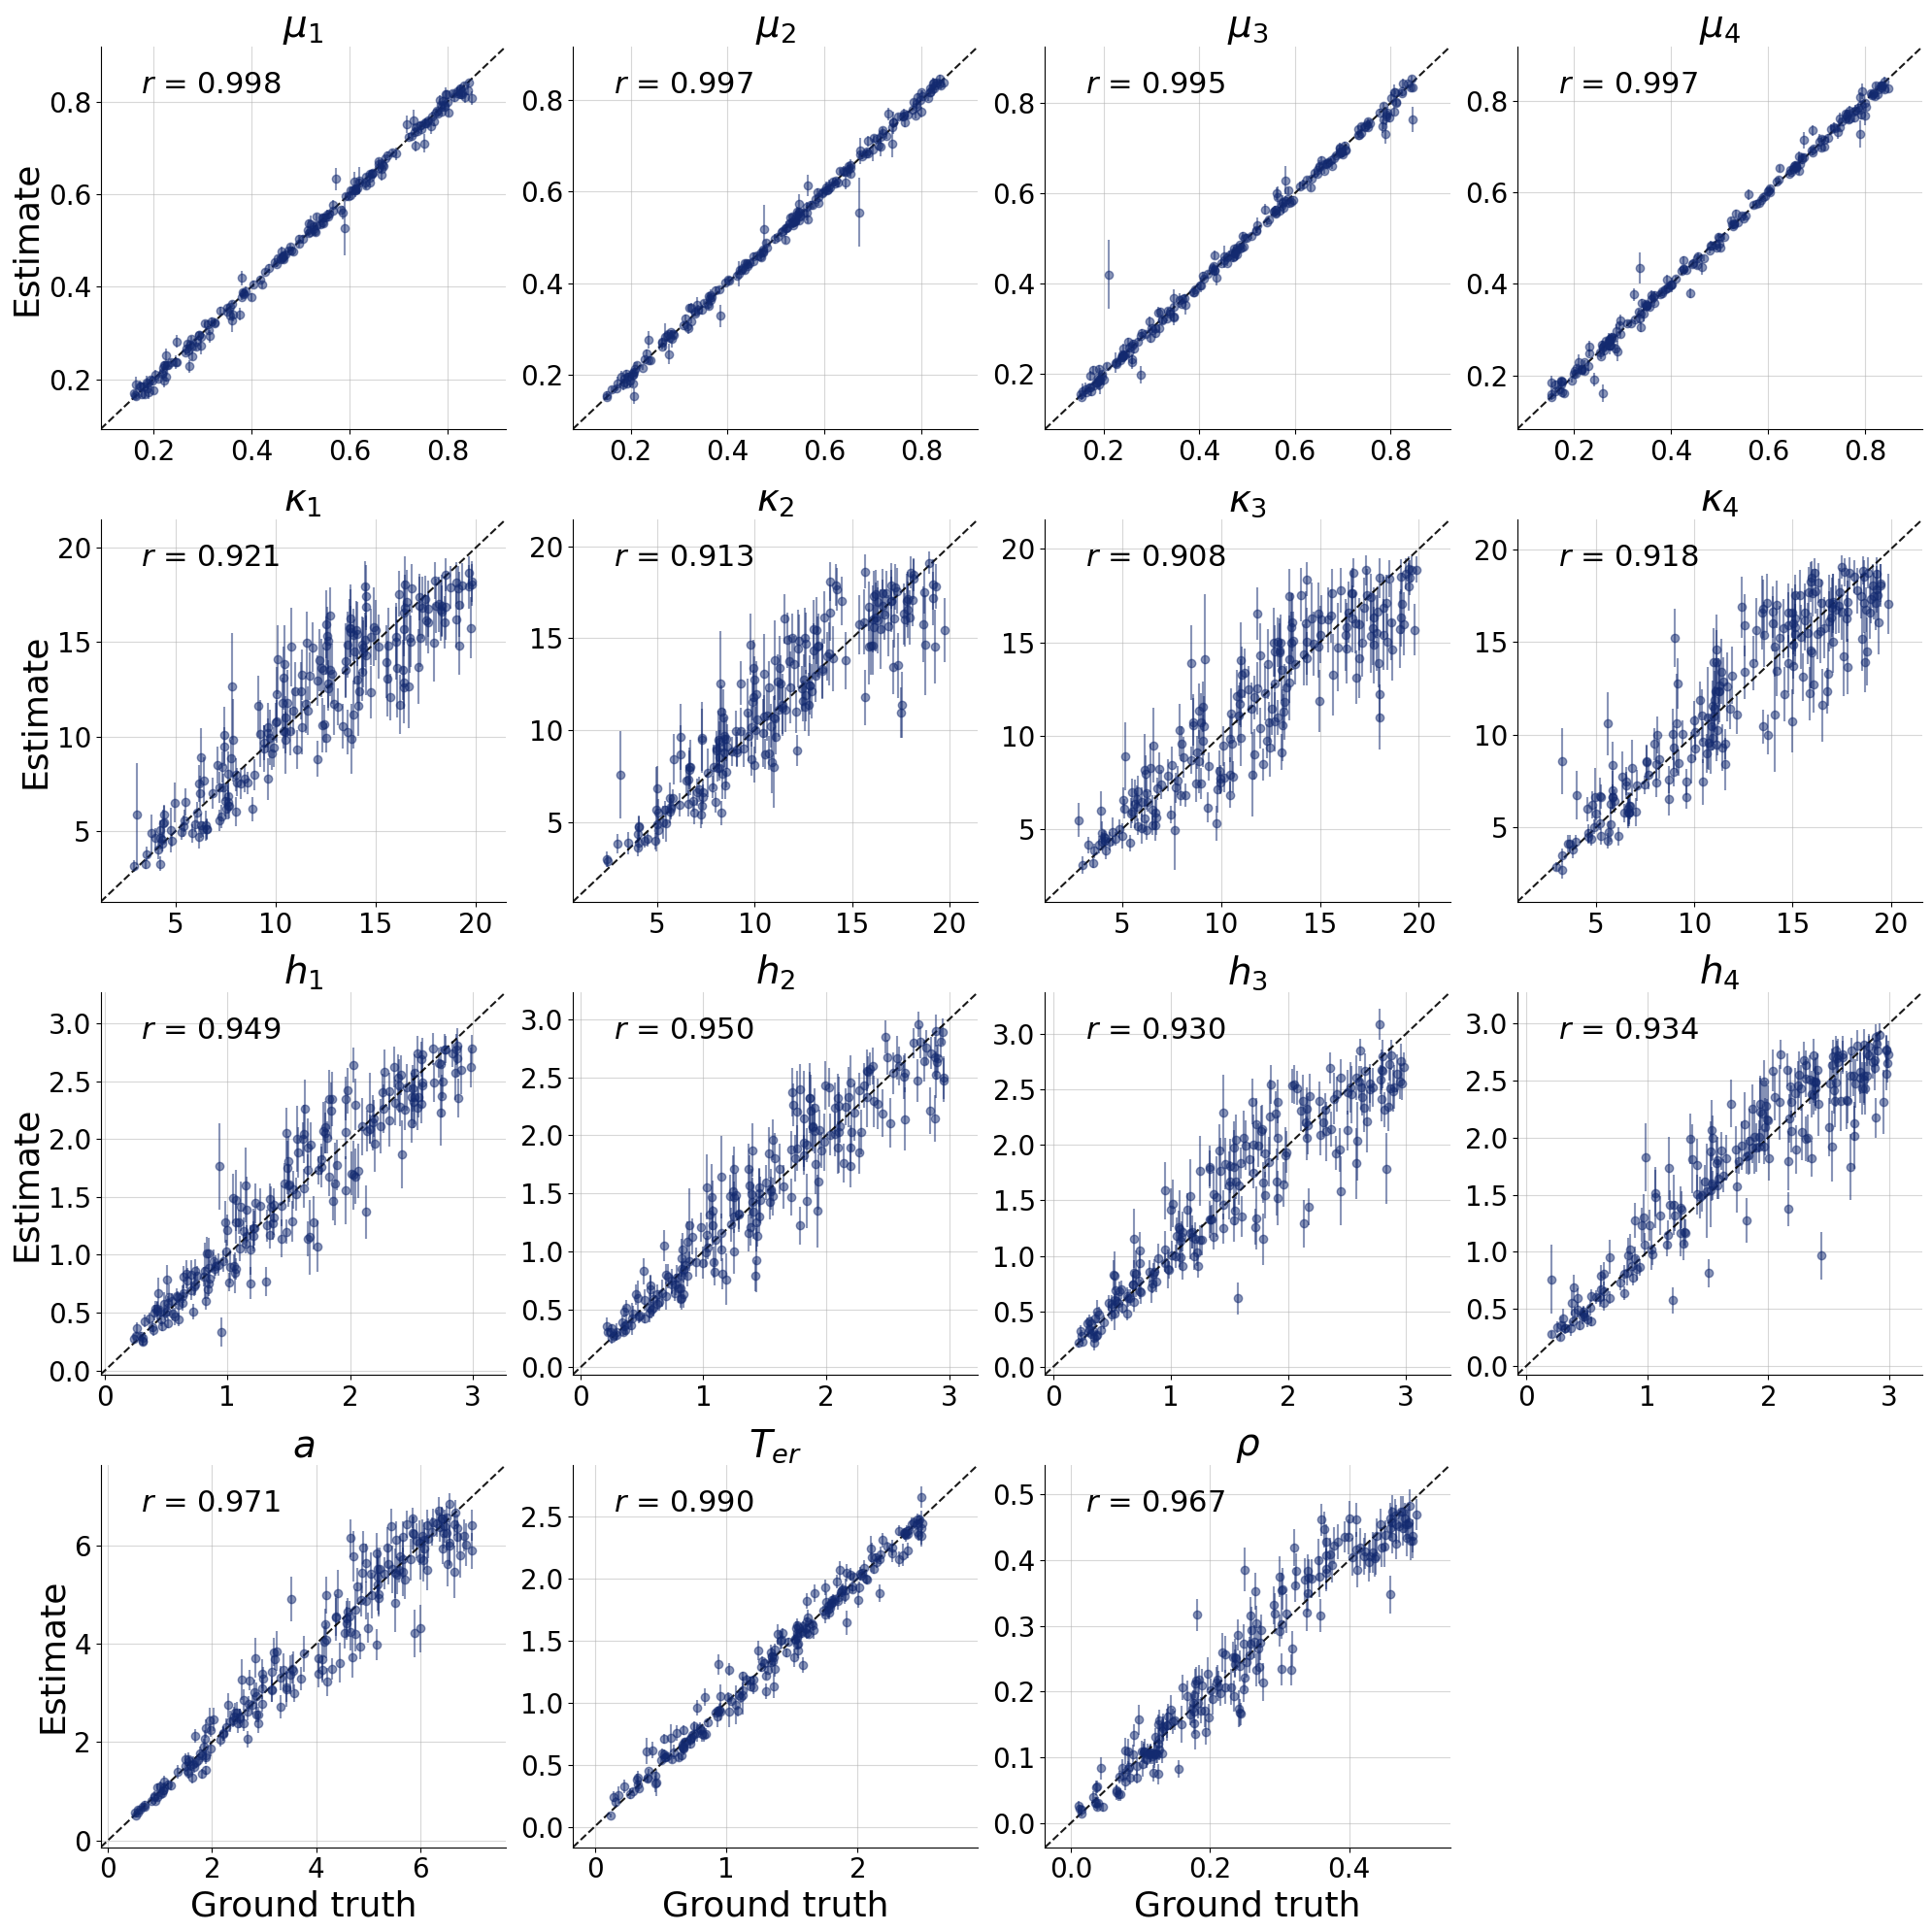

In [18]:
variable_names = [r'$\mu_1$', r'$\mu_2$', r'$\mu_3$', r'$\mu_4$', 
                  r'$\kappa_1$', r'$\kappa_2$', r'$\kappa_3$', r'$\kappa_4$',
                  r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$',
                  r'$a$', r'$T_{er}$', r'$\rho$']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws, 
    targets=val_sims,
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20
)


f.savefig('../plots/bddm_recovery.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

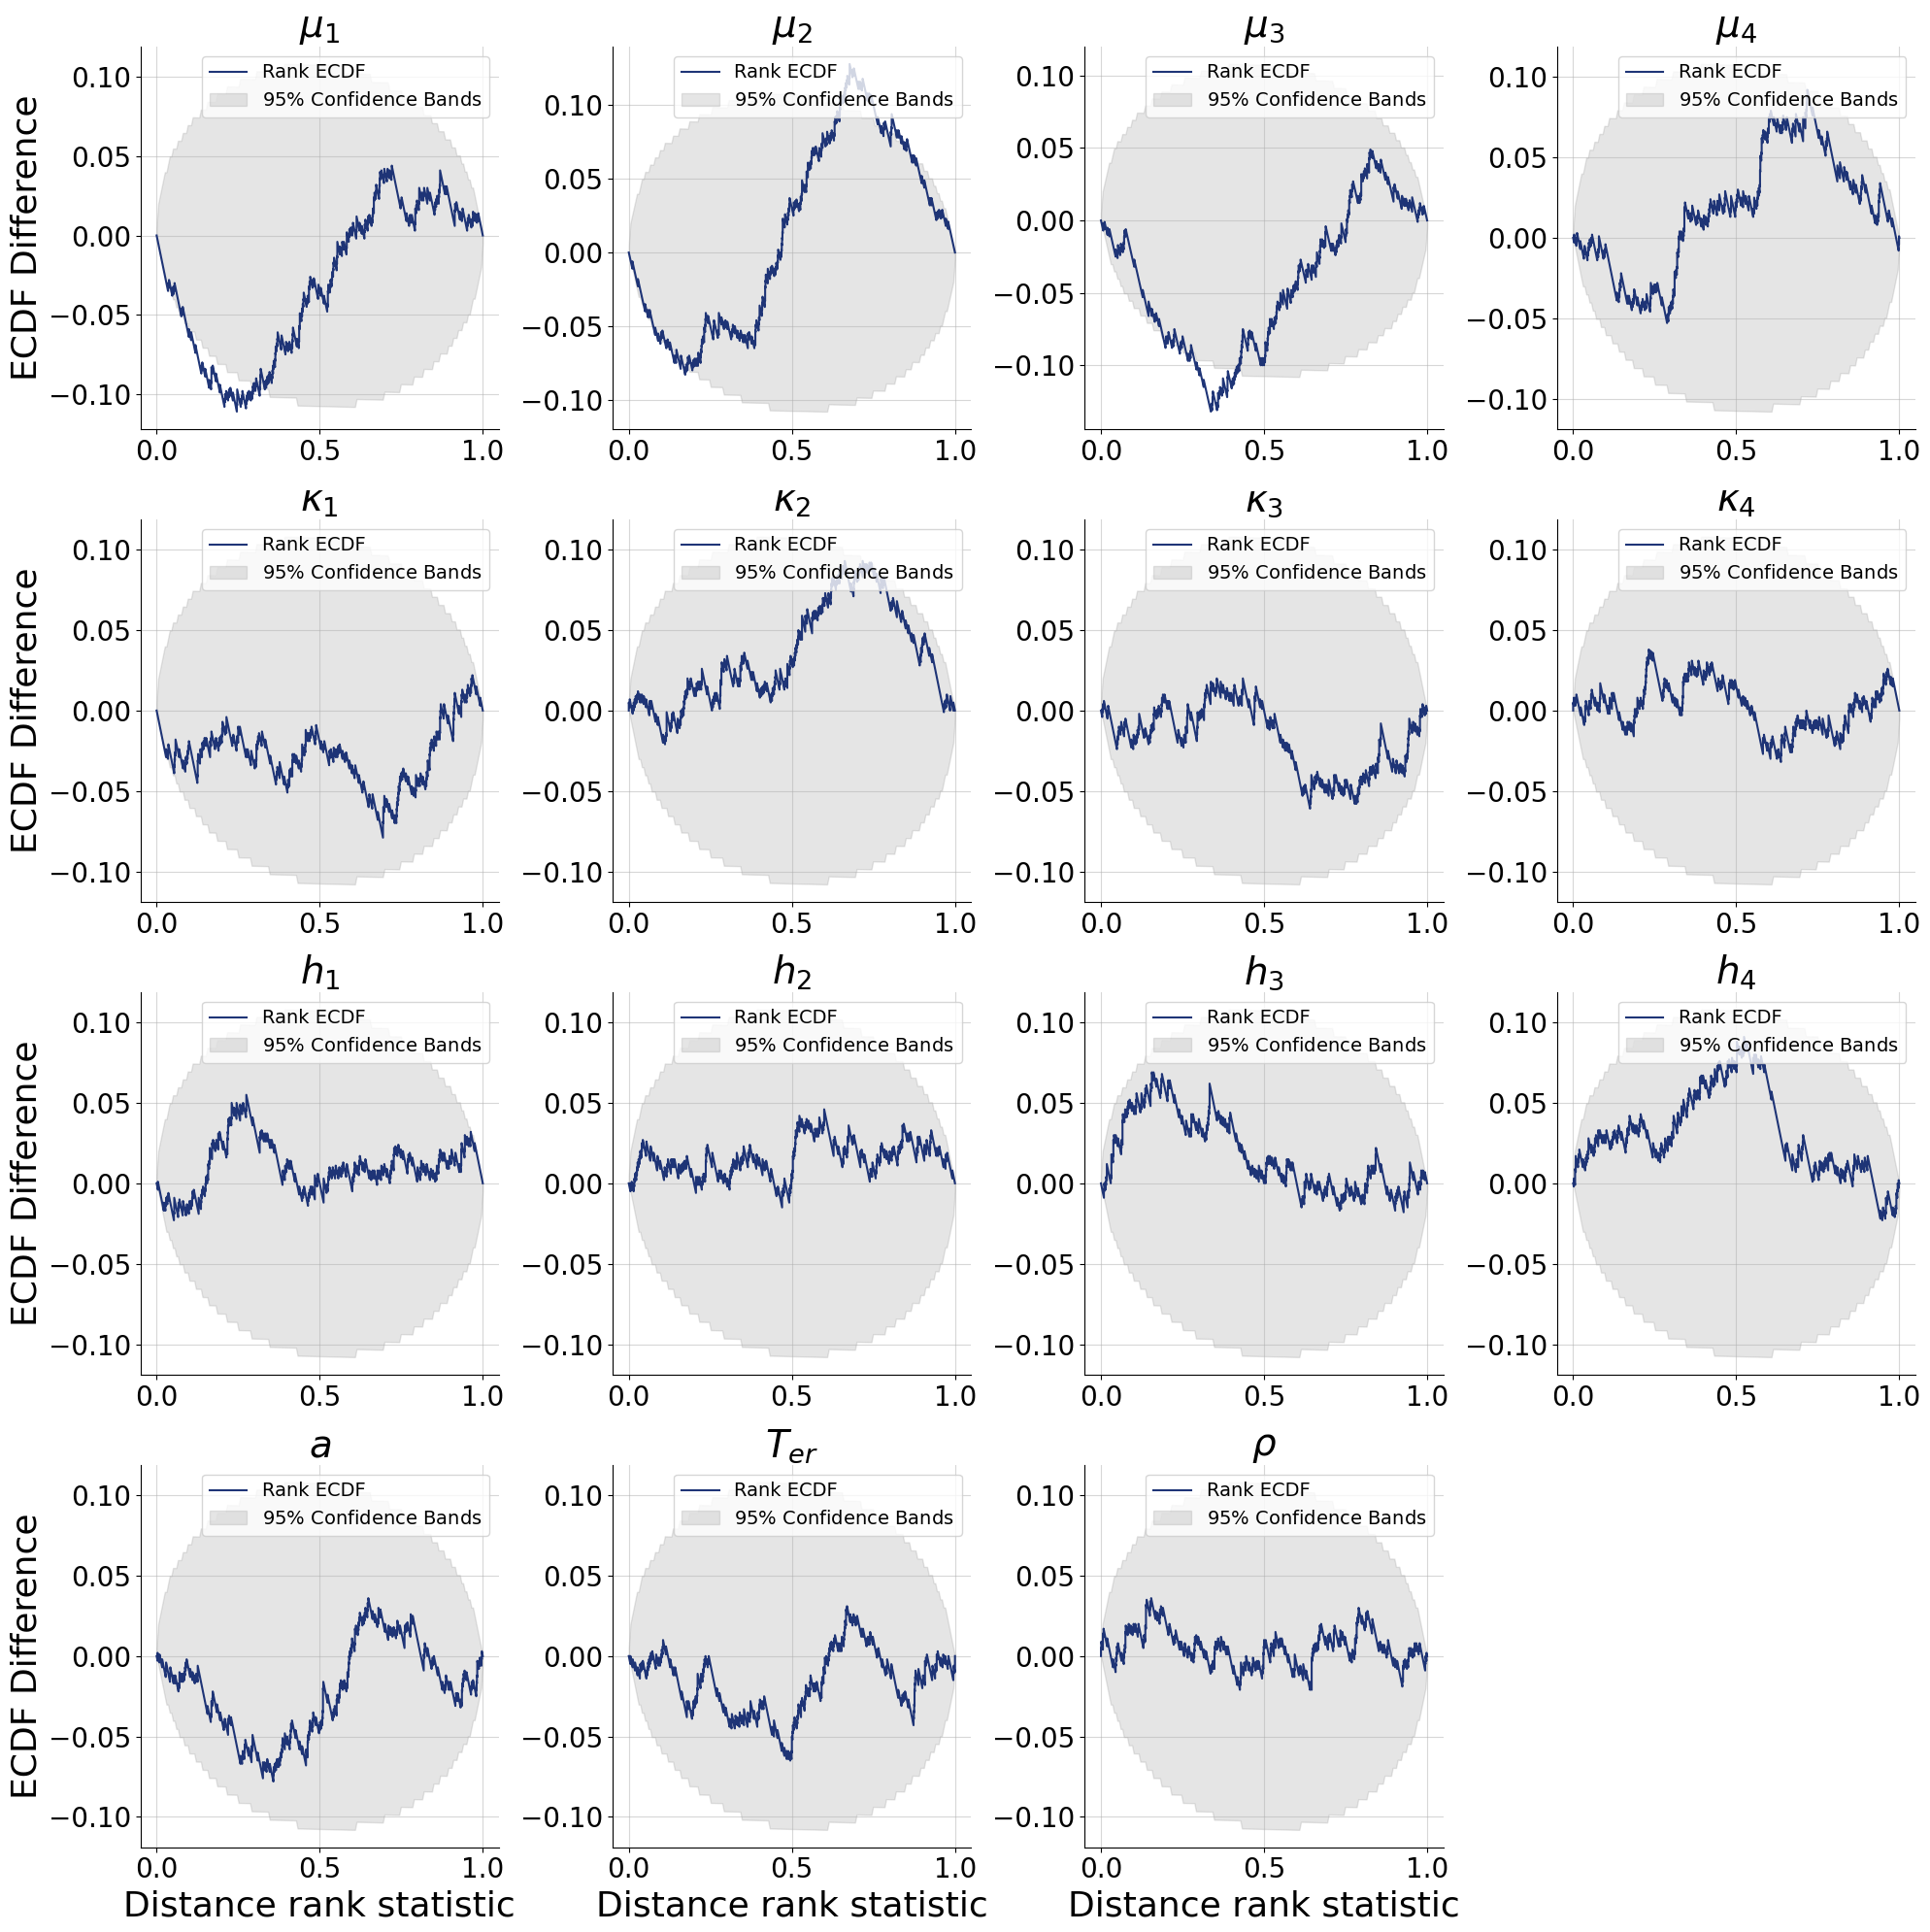

In [19]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=post_draws, 
    targets=val_sims,
    difference = True,
    rank_type="distance",
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20

)

f.savefig('../plots/bddm_ecdf.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

## data fitting

In [22]:
data = pd.read_table("../notebooks_gpu/affect_data_bf.txt", sep = " ")

data["affect"] = math.pi * data["affect"]/100

In [23]:
def data_organize(data):    
    grouped = data.groupby("participant")[["rt", "affect"]].agg(list)
    grouped_outcomes = data.groupby("participant")["outcome"].agg(list)
    outcome_values = np.array([-2, -1, 1, 2])
    outcome_to_index = {val: idx for idx, val in enumerate(outcome_values)}
    
    max_obs = 200
    rt_padded = np.zeros((len(grouped), max_obs))
    rt_min = np.zeros(len(grouped))
    resp_padded = np.zeros((len(grouped), max_obs))
    mask = np.zeros((len(grouped), max_obs), dtype=int)
    con = np.zeros((len(grouped), max_obs, 4), dtype=int)

    for i, (participant_id, outcomes) in enumerate(grouped_outcomes.items()):
        num_trials = min(len(outcomes), 200)
        
        # Iterate through the actual trials for the current participant
        for t in range(num_trials):
            outcome_val = outcomes[t]
            
            # Determine the column index for the current outcome
            col_index = outcome_to_index.get(outcome_val)
            
            # Only proceed if the outcome is one of the four expected values
            if col_index is not None:
                # Set the corresponding position in the 3D array to 1
                # (Participant index, Trial index, Outcome index)
                con[i, t, col_index] = 1

    
    for i, (_, row) in enumerate(grouped.iterrows()):
        rt_list = row["rt"]
        resp_list = row["affect"]
        n = min(len(rt_list), max_obs)
        rt_padded[i, :n] = rt_list[:n]
        resp_padded[i, :n] = resp_list[:n]
        rt_min[i] = np.min(row["rt"])
        mask[i, :n] = 1

    data_dict = {}
    data_dict["num_obs_per_condition"] = data.groupby("participant")["outcome"].value_counts().unstack(fill_value=0).to_numpy()
    data_dict["rt"] = rt_padded
    data_dict["resp"] = resp_padded
    data_dict["observed"] = mask
    data_dict["rt_min"] = rt_min.reshape((215,1))
    data_dict["con"] = con
    
    return data_dict
    
    


In [25]:
data_re = data_organize(data)
%time post_draws = workflow.sample(conditions=data_re, num_samples=1000)

CPU times: user 125 ms, sys: 16.9 ms, total: 142 ms
Wall time: 664 ms


In [26]:
mu_mean = [np.mean(post_draws["mu"], axis=1)[:,i] for i in range(4)]
kappa_mean = [np.mean(post_draws["kappa"], axis=1)[:,i] for i in range(4)]
h_mean = [np.mean(post_draws["h"], axis=1)[:,i] for i in range(4)]
a_mean = np.mean(post_draws["a"], axis = 1)

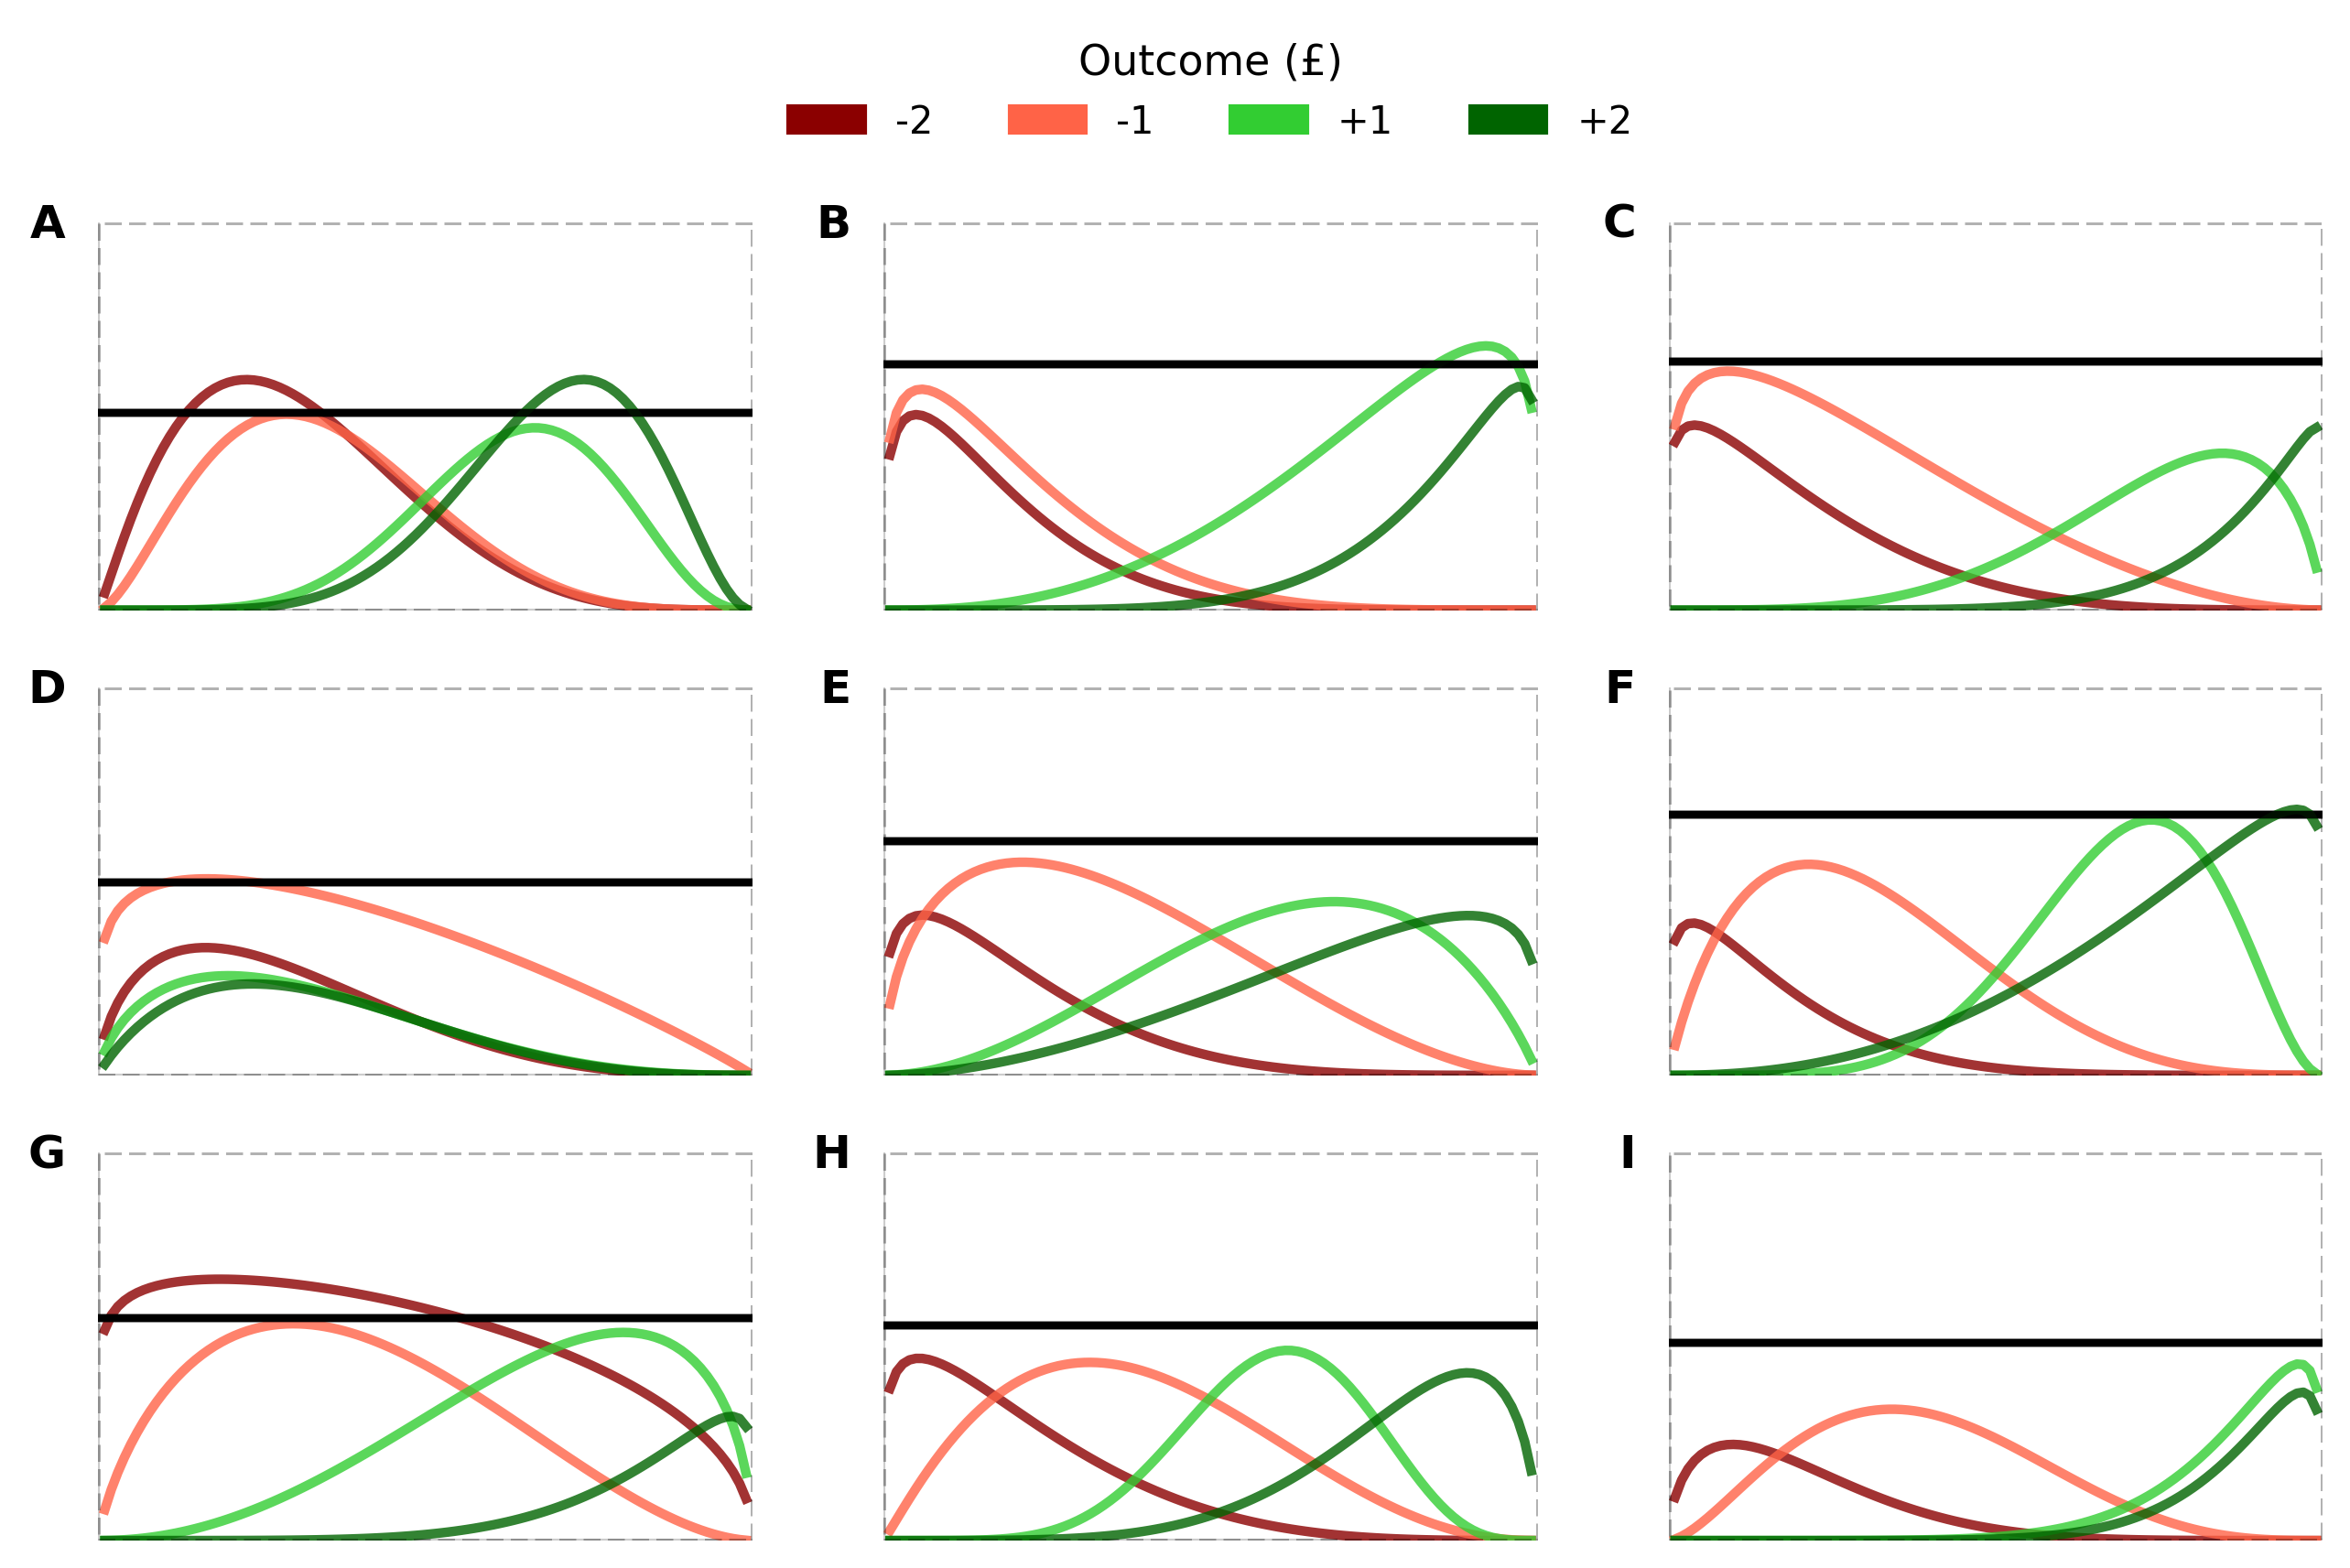

In [28]:
from matplotlib.patches import Rectangle
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2

# Create figure with higher DPI for better quality
fig, ax = plt.subplots(3, 3, figsize=(9, 6), dpi=300)
ax = ax.flatten()

# Define a more professional color palette
# Consider colorblind-friendly options
colors = ['#8B0000', '#FF6347', '#32CD32', '#006400']  # or use plt.cm.Set2.colors
x = np.linspace(0.01, 0.99, 100)
for i in range(1,10):    
    for j in range(4):
        ax[i-1].plot(x, h_mean[j][i] * beta.pdf(x, mu_mean[j][i] * kappa_mean[j][i], kappa_mean[j][i] - mu_mean[j][i] * kappa_mean[j][i]),
                lw = 2.5, color = colors[j], alpha=0.8)
        ax[i-1].hlines(a_mean[i], xmin = 0, xmax = 1, alpha = 0.8, lw=2, color = "black")
    
    # Lighter, thinner reference lines
    ax[i-1].axhline(0, color='#CCCCCC', linewidth=1, ls='-', zorder=0)
    ax[i-1].axvline(0, color='#CCCCCC', linewidth=1, ls='-', zorder=0)
    
    ax[i-1].set_xlim(0, 1)
    ax[i-1].set_ylim(0, 4.5)
    ax[i-1].axis('off')

    # === Add square border around each subplot ===
    rect = Rectangle(
        (0, 0), 1, 1,                # position and size in axes coordinates
        transform=ax[i-1].transAxes,   # use axes coordinates (0–1)
        linewidth=1.2,
        edgecolor='black',
        facecolor='none',
        zorder=10,
        ls="--",
        alpha = 0.3
    )
    ax[i-1].add_patch(rect)
    
# Tighter layout
plt.subplots_adjust(wspace=0.2, hspace=0.2, top=0.85, bottom=0.05, left=0.05, right=0.95)

# Optional: Add panel labels (A, B, C, etc.)
for i, axis in enumerate(ax):
    axis.text(-0.05, 1.05, chr(65+i), transform=axis.transAxes,
              fontsize=12, fontweight='bold', va='top', ha='right')

labels = ['-2', '-1', '+1', '+2']

# Create custom legend handles
from matplotlib.patches import Patch
handles = [Patch(color=colors[j % len(colors)], label=labels[j]) for j in range(4)]

# Place the legend outside the grid
fig.legend(handles=handles, 
           title='Outcome (£)',
           loc='upper center',        # position below all subplots
           bbox_to_anchor=(0.5, 0.98),
           ncol=4,                    # put all labels in one row
           frameon=False,             # remove legend box border
           fontsize=10,
           title_fontsize=11)

# Save in multiple formats
plt.savefig('../plots/bddm_example.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## Correlation between parameter and summary statistics

In [29]:
mean_resp = np.zeros((215, 4))
var_resp  = np.zeros((215, 4))
mean_rt   = np.zeros((215, 4))
var_rt    = np.zeros((215, 4))

for n in range(215):
    for c in range(4):
        idx = data_re["con"][n, :, c] == 1

        resp_vals = data_re["resp"][n, idx]
        rt_vals   = data_re["rt"][n, idx]

        mean_resp[n, c] = np.mean(resp_vals)
        var_resp[n, c]  = np.var(resp_vals)

        mean_rt[n, c] = np.mean(rt_vals)
        var_rt[n, c]  = np.var(rt_vals)
a_repeat = np.repeat(np.mean(post_draws["a"], axis=1), 4, axis = 1)
rho_repeat = np.repeat(np.mean(post_draws["rho"], axis=1), 4, axis = 1)
Ter_repeat = np.repeat(np.mean(post_draws["ndt"], axis=1), 4, axis = 1)

In [30]:
mu_posmean = np.mean(post_draws["mu"], axis=1)
kappa_posmean = np.mean(post_draws["kappa"], axis=1)
h_posmean = np.mean(post_draws["h"], axis=1)
height_drift = np.zeros((215, 4))
mode_drift = np.zeros((215, 4))
IQR_drift = np.zeros((215, 4))


for i in range(215):
    for c in range(4):
        height_drift[i,c] = np.max(h_posmean[i,c] * beta.pdf(x, mu_posmean[i,c] * kappa_posmean[i,c], kappa_posmean[i,c] - mu_posmean[i,c] * kappa_posmean[i,c]))
        Q1 = beta.ppf(0.25, mu_posmean[i,c] * kappa_posmean[i,c], kappa_posmean[i,c] - mu_posmean[i,c] * kappa_posmean[i,c])
        Q3 = beta.ppf(0.75, mu_posmean[i,c] * kappa_posmean[i,c], kappa_posmean[i,c] - mu_posmean[i,c] * kappa_posmean[i,c])
        IQR_drift[i,c] = Q3- Q1
        mode_drift[i,c] = (mu_posmean[i,c] * kappa_posmean[i,c] - 1)/(kappa_posmean[i,c] - 2)

height_drift_a_ratio = height_drift/a_repeat

### Mean RT

In [31]:
ndt = np.tile(np.mean(post_draws["ndt"], axis=1), (1,4))
mean_rt = mean_rt - ndt

In [32]:
def dict_cor(target):
    predictors = {
        "h": h_posmean.flatten(),
        "mu": mu_posmean.flatten(),
        "kappa": kappa_posmean.flatten(),
        "height": height_drift.flatten(),
        "mode": mode_drift.flatten(),
        "IQR": IQR_drift.flatten(),
        "a": a_repeat.flatten(),
        "rho": rho_repeat.flatten(),
        "Ter": Ter_repeat.flatten(),
        "drift_a_ratio": height_drift_a_ratio.flatten(),
    }
    
    corrs = {
        name: np.round(np.corrcoef(target.flatten(), values)[0, 1], 3)
        for name, values in predictors.items()
    }
    return corrs

In [33]:
dict_cor(mean_rt)

{'h': -0.198,
 'mu': -0.025,
 'kappa': -0.067,
 'height': -0.306,
 'mode': -0.021,
 'IQR': 0.046,
 'a': 0.696,
 'rho': 0.025,
 'Ter': -0.046,
 'drift_a_ratio': -0.717}

In [34]:
dict_cor(var_rt)

{'h': -0.243,
 'mu': 0.002,
 'kappa': -0.109,
 'height': -0.495,
 'mode': 0.002,
 'IQR': 0.133,
 'a': 0.088,
 'rho': 0.053,
 'Ter': -0.163,
 'drift_a_ratio': -0.479}

In [35]:
dict_cor(mean_resp)

{'h': -0.247,
 'mu': 0.984,
 'kappa': 0.119,
 'height': -0.12,
 'mode': 0.991,
 'IQR': -0.222,
 'a': 0.022,
 'rho': -0.005,
 'Ter': -0.014,
 'drift_a_ratio': -0.123}

In [36]:
dict_cor(var_resp)

{'h': -0.028,
 'mu': -0.105,
 'kappa': -0.2,
 'height': -0.459,
 'mode': -0.103,
 'IQR': 0.405,
 'a': -0.388,
 'rho': 0.047,
 'Ter': 0.133,
 'drift_a_ratio': -0.144}

## Correlation between parameters and summary statistics visualization

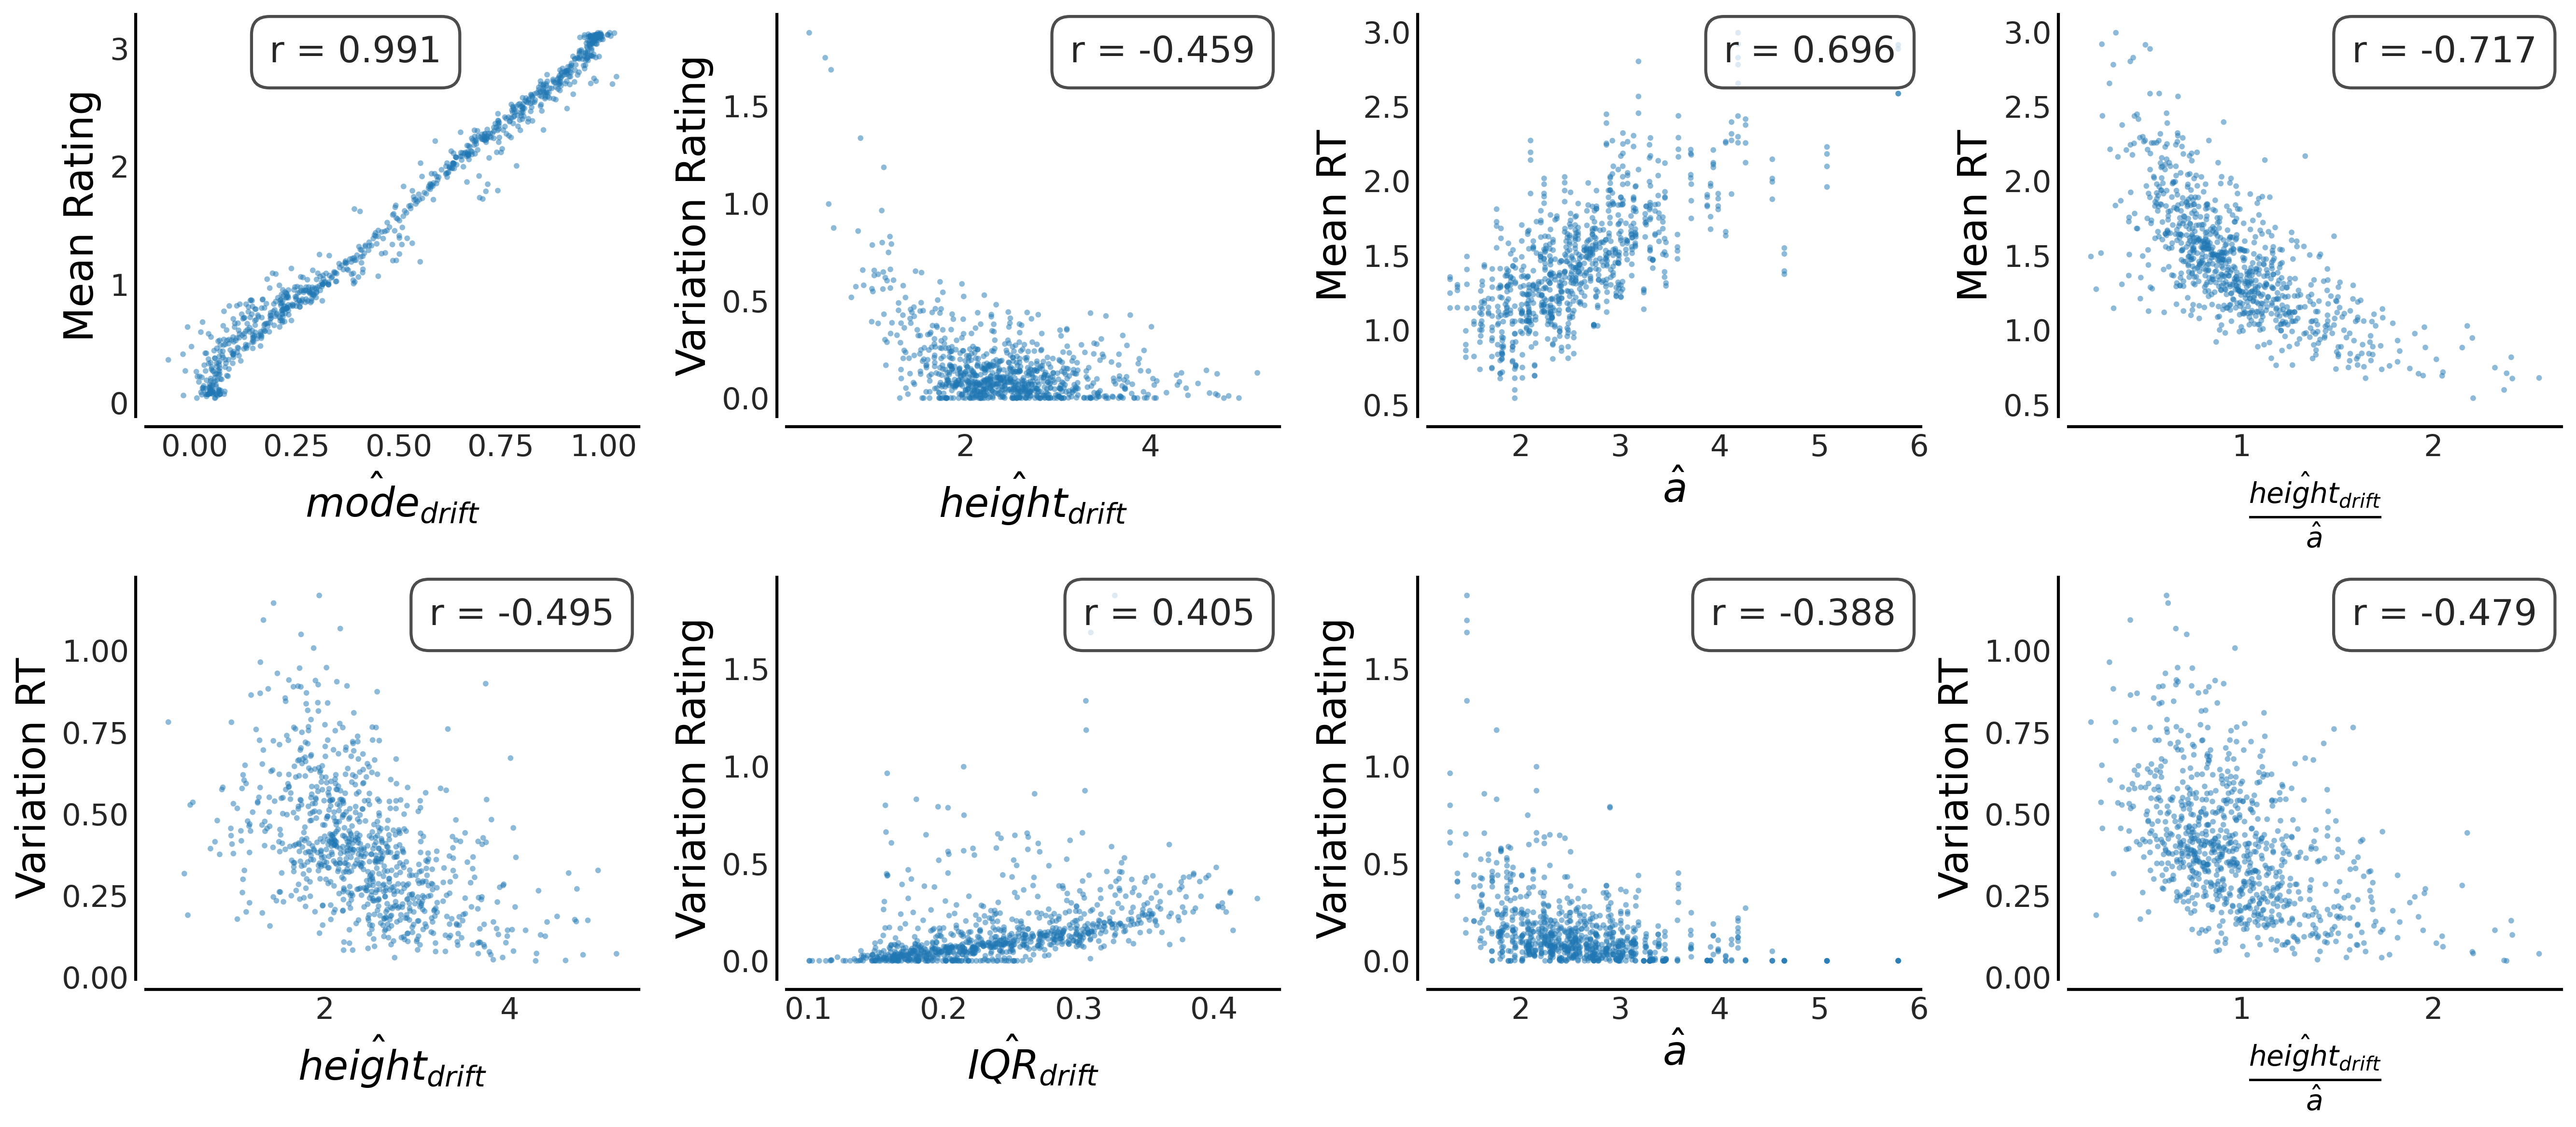

In [37]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8), dpi=300)
plt.style.use("seaborn-v0_8-white")

# Common style
marker_kws = dict(s=8, alpha=0.5, edgecolors='none')
BBOX_PROPS = dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7, edgecolor='black', linewidth=1.5)
CORR_TEXT_KWS = dict( horizontalalignment='right', verticalalignment='top')

#ax[0, 0].scatter(np.mean(post_draws["mu"], axis=1).flatten(),mean_resp.flatten(), **marker_kws)
ax[0, 0].scatter(mode_drift.flatten(),mean_resp.flatten(), **marker_kws)
ax[0, 0].set_ylabel("Mean Rating", fontsize=20)
ax[0, 0].set_xlabel(r'$\hat{mode}_{drift}$', fontsize=20)
ax[0, 0].text(0.6, 0.95,f'r = {np.corrcoef(mean_resp.flatten(),mode_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 0].transAxes, **CORR_TEXT_KWS)


ax[1, 0].scatter(height_drift.flatten(), var_rt.flatten(), **marker_kws)
ax[1, 0].set_ylabel("Variation RT", fontsize=20)
ax[1, 0].set_xlabel(r'$\hat{height}_{drift}$', fontsize=20)
ax[1, 0].text(0.95, 0.95,f'r = {np.corrcoef(var_rt.flatten(),height_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 0].transAxes, **CORR_TEXT_KWS)


ax[0, 1].scatter(height_drift.flatten(), var_resp.flatten(), **marker_kws)
ax[0, 1].set_ylabel("Variation Rating", fontsize=20)
ax[0, 1].set_xlabel(r'$\hat{height}_{drift}$', fontsize=20)
ax[0, 1].text(0.95, 0.95,f'r = {np.corrcoef(var_resp.flatten(),height_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 1].transAxes, **CORR_TEXT_KWS)


ax[1, 1].scatter(IQR_drift.flatten(), var_resp.flatten(), **marker_kws)
ax[1, 1].set_ylabel("Variation Rating", fontsize=20)
ax[1, 1].set_xlabel(r'$\hat{IQR}_{drift}$', fontsize=20)
ax[1, 1].text(0.95, 0.95, f'r = {np.corrcoef(var_resp.flatten(),IQR_drift.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 1].transAxes, **CORR_TEXT_KWS)


ax[0, 2].scatter(a_repeat.flatten(), mean_rt.flatten(), **marker_kws)
ax[0, 2].set_ylabel("Mean RT", fontsize=20)
ax[0, 2].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[0, 2].text(0.95, 0.95,f'r = {np.corrcoef(mean_rt.flatten(),a_repeat.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 2].transAxes, **CORR_TEXT_KWS)

ax[1, 2].scatter(a_repeat.flatten(), var_resp.flatten(), **marker_kws)
ax[1, 2].set_ylabel("Variation Rating", fontsize=20)
ax[1, 2].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[1, 2].text(0.95, 0.95,f'r = {np.corrcoef(var_resp.flatten(),a_repeat.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 2].transAxes, **CORR_TEXT_KWS)


ax[0, 3].scatter(height_drift_a_ratio.flatten(), mean_rt.flatten(), **marker_kws)
ax[0, 3].set_ylabel("Mean RT", fontsize=20)
ax[0, 3].set_xlabel(r'$\frac{\hat{height}_{drift}}{\hat{a}}$', fontsize=20)
ax[0, 3].text(0.95, 0.95,f'r = {np.corrcoef(mean_rt.flatten(),height_drift_a_ratio.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[0, 3].transAxes, **CORR_TEXT_KWS)


ax[1, 3].scatter(height_drift_a_ratio.flatten(), var_rt.flatten(), **marker_kws)
ax[1, 3].set_ylabel("Variation RT", fontsize=20)
ax[1, 3].set_xlabel(r'$\frac{\hat{height}_{drift}}{\hat{a}}$', fontsize=20)
ax[1, 3].text(0.95, 0.95,f'r = {np.corrcoef(var_rt.flatten(),height_drift_a_ratio.flatten())[1,0]:.3f}', size = 18, bbox=BBOX_PROPS, transform=ax[1, 3].transAxes, **CORR_TEXT_KWS)



# Polish axes
for a in ax.flatten():
    a.tick_params(labelsize=15)
    sns.despine(ax=a, offset=5)  # clean up top/right borders

plt.tight_layout(pad=1.5)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for ax in fig.axes:
    if not ax.has_data():
        ax.remove()
plt.savefig('../plots/bddm_correlation.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


In [62]:
bddm_estimates = {}
for key in post_draws.keys():
    bddm_estimates[key] = np.mean(post_draws[key], axis = 1)
bddm_estimates["height_drift"] = height_drift
bddm_estimates["height_drift_a_ratio"] = height_drift_a_ratio
bddm_estimates["mode_drift"] = mode_drift
bddm_estimates["IQR_drift"] = IQR_drift

%store bddm_estimates

Stored 'bddm_estimates' (dict)


## Posterior predictive distribution

In [38]:
def ppc(batch_info):
    theta = prior                # batched
    batch_size = theta["rho"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=RNG)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }

In [39]:
post_draws = workflow.sample(conditions=data_re, num_samples=2000)

prior = {}
n_replicates = 100
mean_rt_ppc = np.zeros((n_replicates, 215,4))
std_rt_ppc = np.zeros((n_replicates, 215,4))
mean_resp_ppc = np.zeros((n_replicates, 215,4))
std_resp_ppc = np.zeros((n_replicates, 215,4))

quantiles_rt_ppc = np.zeros((n_replicates, 215,4, 5))
quantiles_resp_ppc = np.zeros((n_replicates, 215,4, 5))
quantile = [0.1, 0.3, 0.5, 0.7, 0.9]


for i in range(n_replicates):
    for key in post_draws.keys():
        idx = np.random.randint(0, post_draws[key].shape[1], size=post_draws[key].shape[0])
        prior[key] = post_draws[key][np.arange(post_draws[key].shape[0]), idx]
    ppc_simulated = ppc(1)
    for n in range(215):
        for c in range(4):
            mean_rt_ppc[i,n,c] = np.mean(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
            std_rt_ppc[i,n,c] = np.std(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
    
            mean_resp_ppc[i,n,c] = np.mean(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            std_resp_ppc[i,n,c] = np.std(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            for q in range(5):
                quantiles_rt_ppc[i,n,c,q] = np.quantile(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])
                quantiles_resp_ppc[i,n,c,q] = np.quantile(ppc_simulated["resp"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])



### Quantiles: 0.1, 0.3, 0.5, 0.7, 0.9

In [40]:
quantiles_rt_obs = np.zeros((215,4, 5))
quantiles_resp_obs = np.zeros((215,4, 5))

quantile = [0.1, 0.3, 0.5, 0.7, 0.9]

for n in range(215):
    for c in range(4):
        for q in range(5):
            #response
            quantiles_rt_obs[n,c,q] = np.quantile(data_re["rt"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
            quantiles_resp_obs[n,c,q] = np.quantile(data_re["resp"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
    


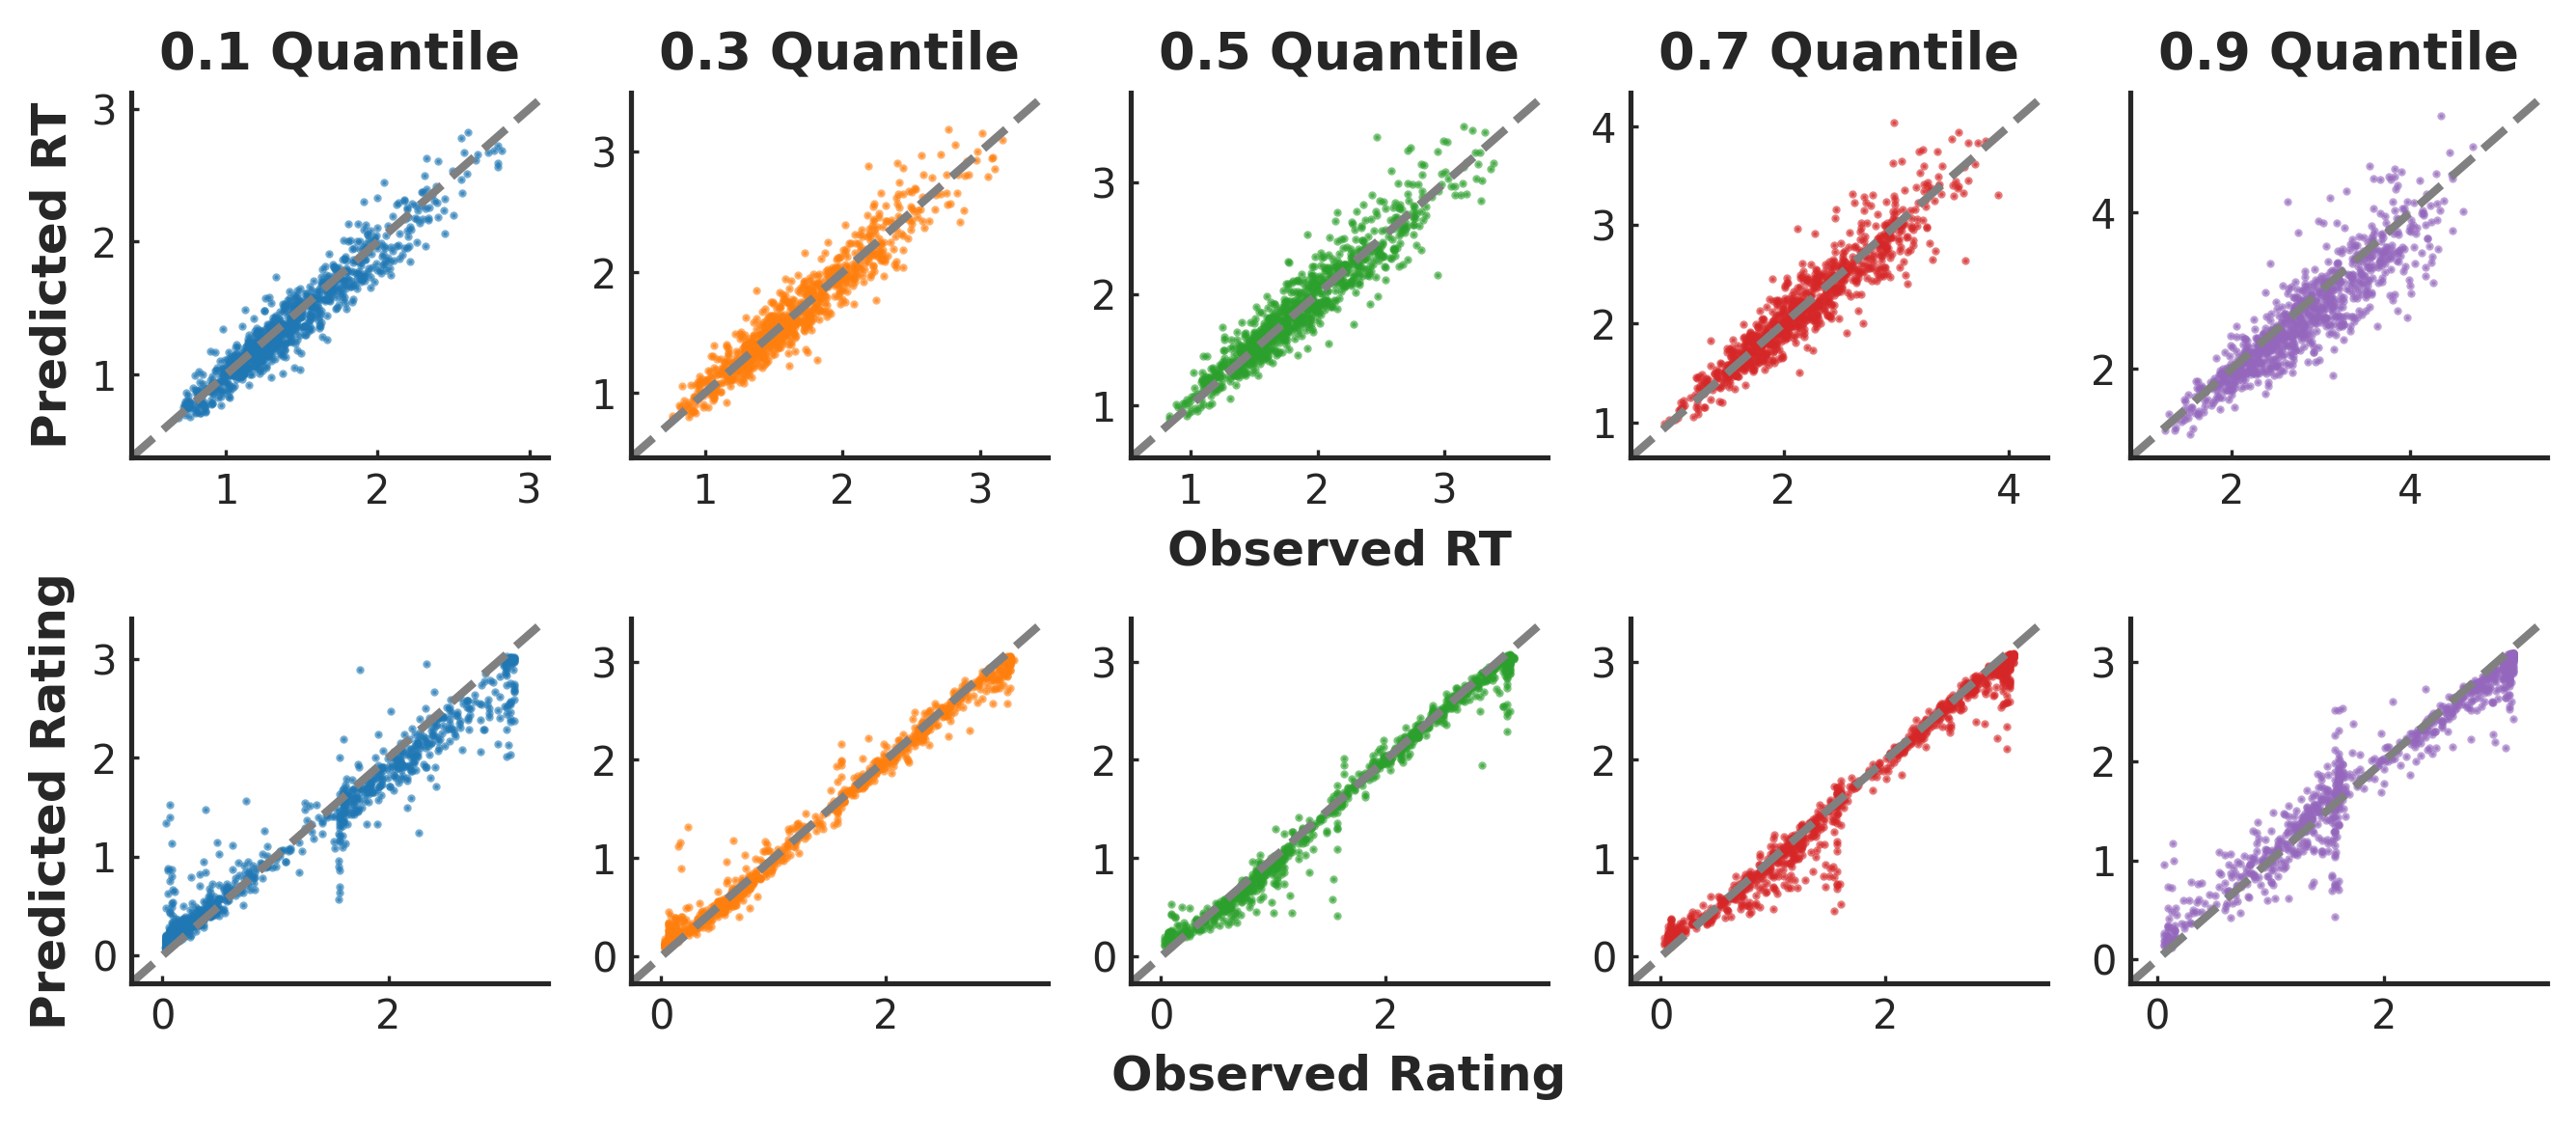

In [41]:
fig, ax = plt.subplots(2, 5, figsize = (9, 4), dpi = 300)
colors = plt.cm.tab10.colors 

for i in range(5):
    quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc[:,:,:,i], axis = 0)
    ax[0, i].scatter(quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[0, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[0, i].set_title(f"{quantile[i]} Quantile", size = 13, weight = "bold")
    ax[0, i].set_xlim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, i].set_ylim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, 2].set_xlabel("Observed RT", size = 12, weight = "bold")
    ax[0, 0].set_ylabel("Predicted RT", size = 12, weight = "bold")
    
for i in range(5):
    quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc[:,:,:,i], axis = 0)
    ax[1, i].scatter(quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[1, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[1, i].set_xlim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, i].set_ylim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, 2].set_xlabel("Observed Rating", size = 12, weight = "bold")
    ax[1, 0].set_ylabel("Predicted Rating", size = 12, weight = "bold")

for a in ax.flatten():
    #a.set_aspect("equal", adjustable="box")
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(direction="in", length=2)
    
plt.tight_layout()
plt.savefig('../plots/quantile_bddm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### Quantify the goodness of fit

In [67]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
gof_resp_bddm = np.mean(np.mean(abs(quantiles_resp_obs - quantiles_resp_ppc_mean), axis = 1), axis = 1)
%store gof_resp_bddm

Stored 'gof_resp_bddm' (ndarray)


In [68]:
quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc, axis = 0)
gof_rt_bddm = np.mean(np.mean(abs(quantiles_rt_obs - quantiles_rt_ppc_mean), axis = 1), axis = 1)
%store gof_rt_bddm

Stored 'gof_rt_bddm' (ndarray)


### Problematic prediction based on ratings

problem 1 is the overestimate of 0.1 quantile when the observed 0.1 quantile is close to 0.

In [69]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
problem_participant = np.where((abs(quantiles_resp_obs[:,:,0] - quantiles_resp_ppc_mean[:,:,0]) > 0.8) & (quantiles_resp_obs[:,:,0]<1))[0][:4]
problem_condition = np.where((abs(quantiles_resp_obs[:,:,0] - quantiles_resp_ppc_mean[:,:,0]) > 0.8) & (quantiles_resp_obs[:,:,0]<1))[1][:4]

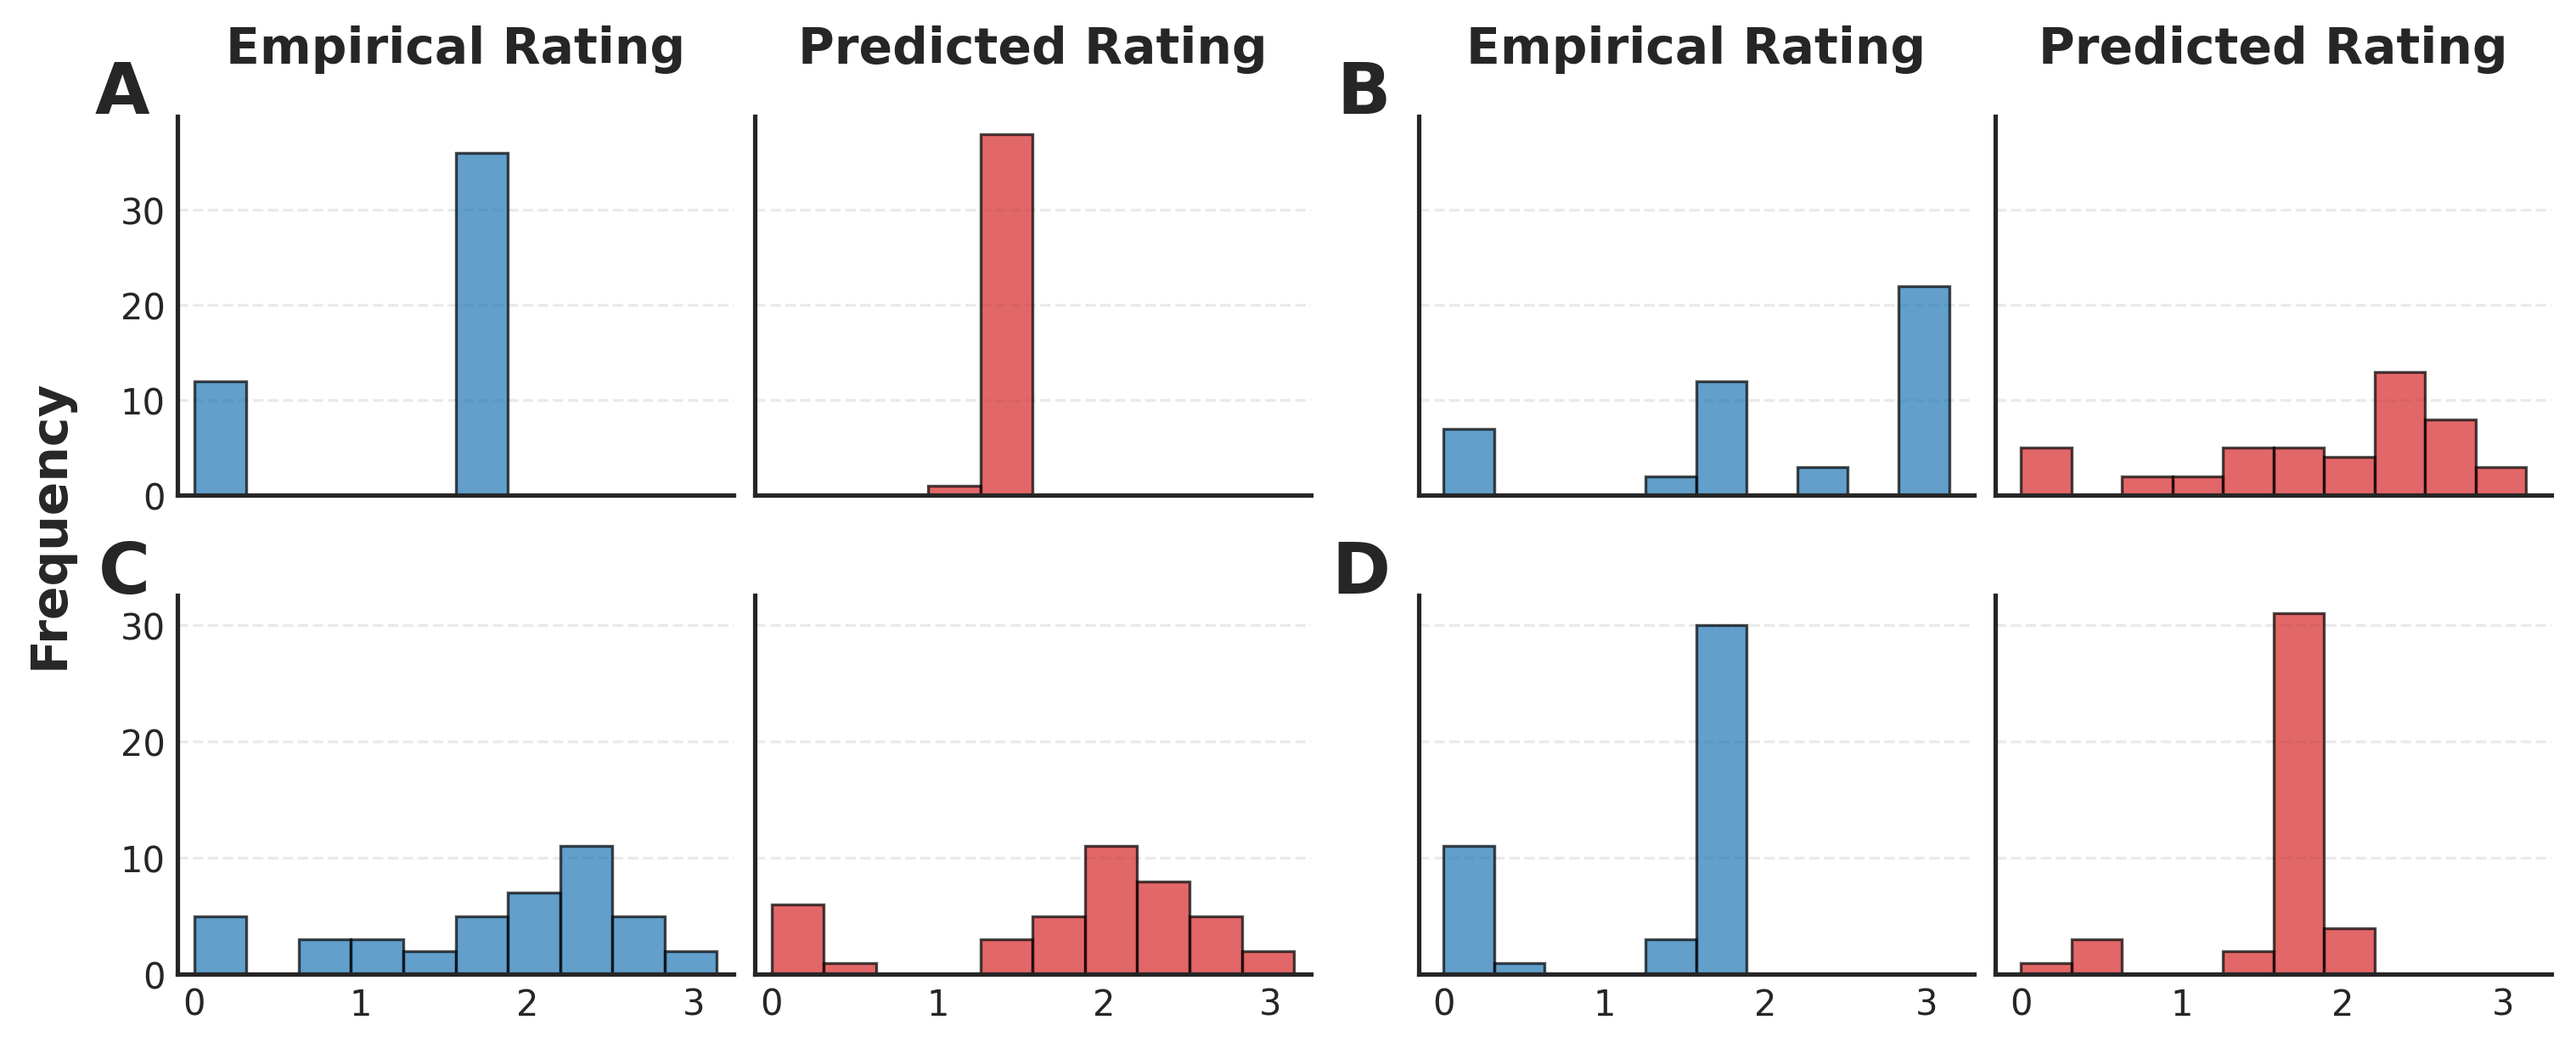

In [70]:
# Define colors and styles
empirical_color = '#1f77b4'  # Muted Blue
predicted_color = '#d62728'  # Muted Red
bin_edges = np.linspace(0, np.pi, 11)  # 10 equal bins across full range
hist_style = {'alpha': 0.7, 'edgecolor': 'black', 'linewidth': 0.8, 'bins': bin_edges}
col_titles = ["Empirical Rating", "Predicted Rating","Empirical Rating", "Predicted Rating"]

num_rows = 2

# 1. Setup the figure
# sharex='col', sharey='row' is still great
fig, ax = plt.subplots(num_rows, 4, figsize=(10, 2 * num_rows), dpi=300, 
                       sharex='col', sharey='row', constrained_layout=True)

# Handle the case of a single row/column, where ax is 1D
axes = ax.flatten()

for i in range(4):
    # --- User Data Logic (Simplified for example) ---
    n = problem_participant[i]
    con = problem_condition[i]
    
    # Simplified data fetch (placeholder logic)
    index = np.where(data_re["con"][n,:][:,con] == 1)
    data_resp = data_re["resp"][n,:][index]
    index_ppc = np.where(ppc_simulated["con"][n,:][:,con] == 1)
    sim_resp = ppc_simulated["resp"][n,:][index_ppc]
    
    # Column 1: Empirical Rating
    axes[2*i].hist(data_resp, color=empirical_color, **hist_style)
    axes[2*i].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # Column 2: Simulated Rating
    axes[2*i+1].hist(sim_resp, color=predicted_color, **hist_style)
    axes[2*i+1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # --- Publication Improvements ---
    
    # 1. ADD ROW LABELS
    # axes[2*(i-1)].set_ylabel(f"P{i+1}", rotation=0, size=12, labelpad=30, 
    #                     fontweight='bold')

    axes[2*i].text(-0.05, 1.15, chr(65+i), transform=axes[2*i].transAxes,
              fontsize=20, fontweight='bold', va='top', ha='right')


    # 2. CLEAN UP SPINES
    for j in range(8):
        axes[j].spines['top'].set_visible(False)
        axes[j].spines['right'].set_visible(False)
        
    


for j, title in enumerate(col_titles):
   ax[0, j].set_title(title, fontsize=14, pad=15, fontweight='bold')

# 6. CONSISTENT X-AXIS LIMITS/TICKS
for j in range(2):
    # Set limits slightly wider than data range
    ax[-1, j].set_xlim(0-0.1, np.pi+0.1)

# 7. GLOBAL LABELS
fig.supylabel("Frequency", fontsize=14, fontweight='bold')
plt.savefig('../plots/prob_rating_bddm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

In [71]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
problem_participant = np.where((abs(quantiles_resp_obs[:,:,2] - quantiles_resp_ppc_mean[:,:,2]) > 0.6) & (quantiles_resp_obs[:,:,0]<2.3))[0][:4]
problem_condition = np.where((abs(quantiles_resp_obs[:,:,2] - quantiles_resp_ppc_mean[:,:,2]) > 0.6) & (quantiles_resp_obs[:,:,0]<2.3))[1][:4]

In [72]:
problem_participant

array([ 17,  17, 120, 120])

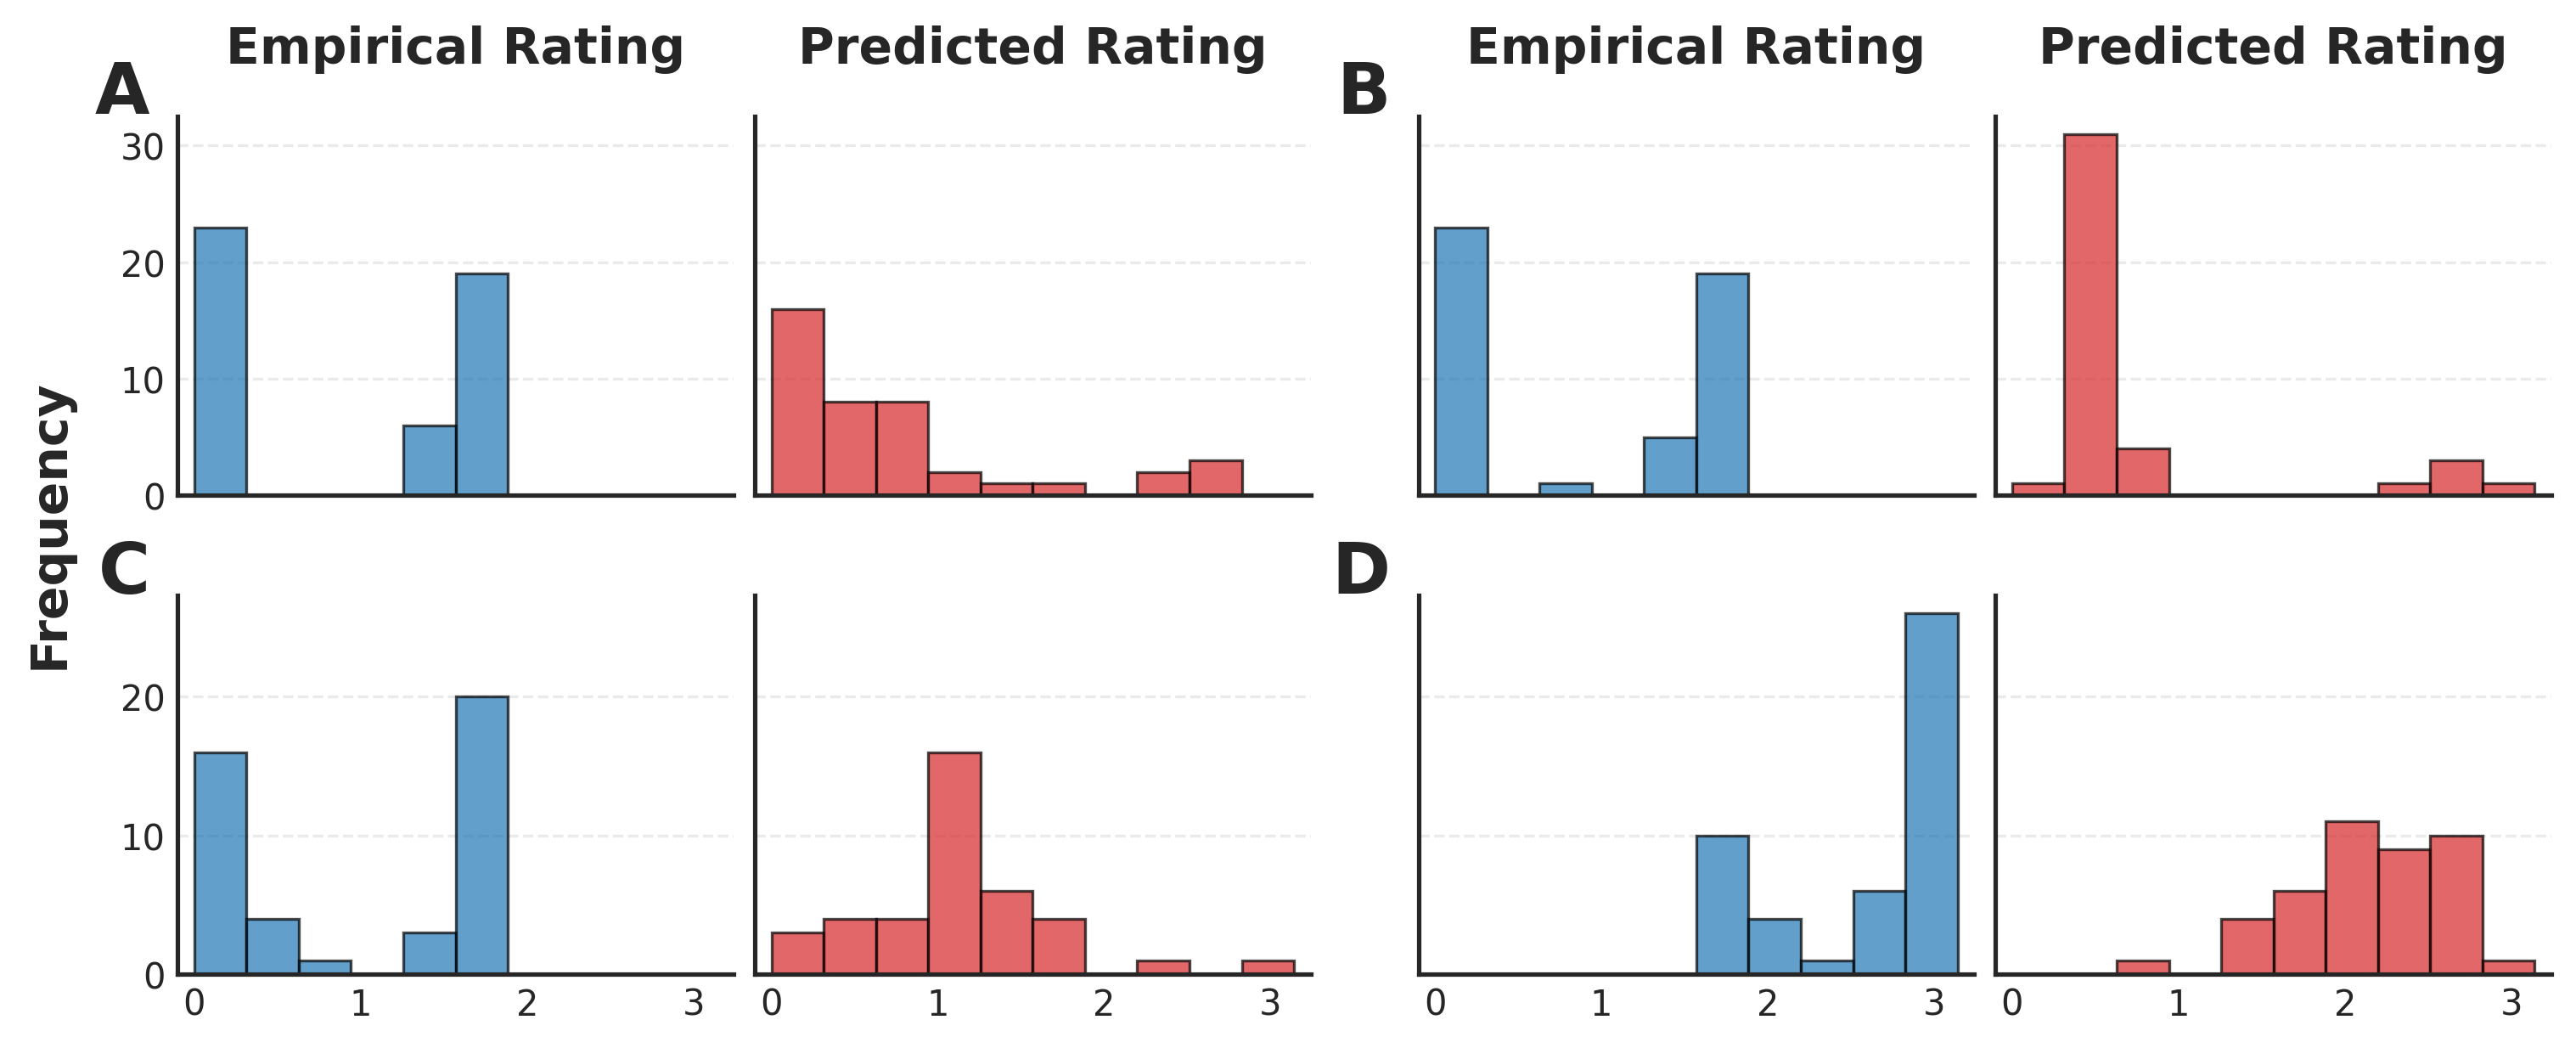

In [73]:
# Define colors and styles
empirical_color = '#1f77b4'  # Muted Blue
predicted_color = '#d62728'  # Muted Red
bin_edges = np.linspace(0, np.pi, 11)  # 10 equal bins across full range
hist_style = {'alpha': 0.7, 'edgecolor': 'black', 'linewidth': 0.8, 'bins': bin_edges}
col_titles = ["Empirical Rating", "Predicted Rating","Empirical Rating", "Predicted Rating"]

# Assuming a standard 1 to 5 rating scale
MIN_RATING = 1
MAX_RATING = 5
num_rows = 2

# 1. Setup the figure
# sharex='col', sharey='row' is still great
fig, ax = plt.subplots(num_rows, 4, figsize=(10, 2 * num_rows), dpi=300, 
                       sharex='col', sharey='row', constrained_layout=True)

# Handle the case of a single row/column, where ax is 1D
axes = ax.flatten()

for i in range(4):
    # --- User Data Logic (Simplified for example) ---
    n = problem_participant[i]
    con = problem_condition[i]
    
    # Simplified data fetch (placeholder logic)
    index = np.where(data_re["con"][n,:][:,con] == 1)
    data_resp = data_re["resp"][n,:][index]
    index_ppc = np.where(ppc_simulated["con"][n,:][:,con] == 1)
    sim_resp = ppc_simulated["resp"][n,:][index_ppc]
    
    # Column 1: Empirical Rating
    axes[2*i].hist(data_resp, color=empirical_color, **hist_style)
    axes[2*i].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # Column 2: Simulated Rating
    axes[2*i+1].hist(sim_resp, color=predicted_color, **hist_style)
    axes[2*i+1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0) # Add subtle grid
    
    # --- Publication Improvements ---
    
    # 1. ADD ROW LABELS
    # axes[2*(i-1)].set_ylabel(f"P{i+1}", rotation=0, size=12, labelpad=30, 
    #                     fontweight='bold')

    axes[2*i].text(-0.05, 1.15, chr(65+i), transform=axes[2*i].transAxes,
              fontsize=20, fontweight='bold', va='top', ha='right')


    # 2. CLEAN UP SPINES
    for j in range(8):
        axes[j].spines['top'].set_visible(False)
        axes[j].spines['right'].set_visible(False)
        
    


for j, title in enumerate(col_titles):
   ax[0, j].set_title(title, fontsize=14, pad=15, fontweight='bold')

# 6. CONSISTENT X-AXIS LIMITS/TICKS
for j in range(4):
    # Set limits slightly wider than data range
    ax[-1, j].set_xlim(0-0.1, np.pi+0.1)

# 7. GLOBAL LABELS
fig.supylabel("Frequency", fontsize=14, fontweight='bold')
plt.savefig('../plots/prob_rating_bddm_2.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()